# KoChatGPT 업그레이드: 데이터 정제와 디코딩 전략을 통한 한국어 RLHF 파이프라인 개선

- 과정: AIFFEL AI 엔지니어 / LLM Trend Note 2 주간 프로젝트
- 작성자: 천세문
- 작성일: 26.07.21
- 한 줄 요약: KoChatGPT의 SFT/RM/PPO 3단계 파이프라인을, 학습 말뭉치 정제와 디코딩 하이퍼파라미터 탐색으로 개선하고 그 효과를 BLEU/ROUGE-L/Distinct-n/RM score로 정량 검증한다.

## 1. 프로젝트 개요

### 목적
KoChatGPT(airobotlab/KoChatGPT)는 InstructGPT의 3단계 학습 절차(SFT -> Reward Model -> PPO)를
한국어 `skt/kogpt2-base-v2` 위에서 재현한 오픈소스다.
다만 학습에 쓰이는 말뭉치가 ChatGPT API로 자동 생성된 것이라 정제 수준이 낮고,
생성 단계의 디코딩 하이퍼파라미터도 고정값을 그대로 쓴다.

이 프로젝트의 목적은 **모델 구조를 바꾸지 않고 데이터와 디코딩만 개선해서
정량 지표가 실제로 올라가는지 검증**하는 것이다.
구조를 고정하면 성능 변화의 원인을 데이터/디코딩으로 특정할 수 있어 분석이 명확해진다.

### 문제 정의
- 입력: 한국어 지시문(instruction) 한 문장. 예) `불고기용 고기 한우에요?`
- 출력: 그 지시문에 대한 한국어 응답 문장.
- 학습 신호: (1) SFT는 지시문-응답 쌍의 교사강요 학습, (2) RM은 응답 쌍의 선호도 순위, (3) PPO는 RM 점수를 보상으로 하는 정책 최적화.

### 데이터셋 한 줄 소개
`KoChatGPT/data_kochatgpt` 폴더의 세 파일을 쓴다.

| 파일 | 개수 | 용도 | 형식 |
|---|---|---|---|
| `kochatgpt_1_SFT.jsonl` | 12,000 | SFT 학습 | `prompt`, `completion` |
| `kochatgpt_2_RM.jsonl` | 10,220 | 보상 모델 학습 | `prompt`, `completion_0/1/2`, `ranking` |
| `kochatgpt_3_PPO.jsonl` | 12,000 | PPO 프롬프트 | `prompt` |

### 이 노트북이 검증하는 가설
1. SFT 말뭉치의 표기 아티팩트와 상투적 거절문을 제거하면 생성 응답의 품질 지표가 오른다.
2. 정제로 줄어든 데이터는 RM 데이터의 1순위 응답을 승격시켜 보충할 수 있다(rejection sampling 방식 증강).
3. 고정 디코딩 대신 하이퍼파라미터를 탐색하면 같은 모델에서도 지표가 더 오른다.

## 2. 목차

3. 실행 환경 및 주의사항
4. 환경 설정 (설치 / 저장소 클론 / import / 시드 / CONFIG)
5. 데이터 로드 및 전처리 (정제 + 증강)
6. 탐색적 데이터 분석 (EDA)
7. 모델 설계 및 구현 (7-1 베이스라인 / 7-2 개선 모델)
8. 학습 (SFT -> RM -> PPO)
9. 평가 및 결과 분석 (정량 지표 + 디코딩 서치 + 정성 샘플)
10. 선행 연구 비교 및 개선점
11. 결론
12. 회고
13. 참고 문헌

## 3. 실행 환경 및 주의사항

### 런타임 설정
Colab 상단 메뉴에서 `런타임 -> 런타임 유형 변경 -> 하드웨어 가속기: T4 GPU`를 선택한 뒤 실행한다.
GPU가 없으면 학습이 사실상 끝나지 않으므로 반드시 확인한다.

### 예상 실행 시간 (Colab 무료 T4 기준)
| 구간 | 예상 시간 |
|---|---|
| 섹션 4 설치 및 클론 | 약 2분 |
| 섹션 5-6 전처리와 EDA | 약 1분 |
| 섹션 8-1 SFT 베이스라인 학습 | 약 6분 |
| 섹션 8-2 SFT 개선본 학습 | 약 7분 |
| 섹션 8-3 RM 학습 | 약 8분 |
| 섹션 8-4 PPO 학습 | 약 10분 |
| 섹션 9 평가 및 디코딩 서치 | 약 8분 |
| 합계 | 약 40~45분 |

### 세션 끊김 대비
- 학습된 모델은 모두 `/content/models/` 아래에 저장된다. 섹션 8의 각 학습 셀은
  이미 저장된 결과가 있으면 학습을 건너뛰도록 작성되어 있으므로, 세션이 끊겨도
  섹션 4부터 다시 실행하면 학습을 반복하지 않는다.
- 결과를 영구 보관하려면 섹션 4의 Google Drive 마운트 셀(선택 사항)을 사용한다.

### OOM(메모리 부족)이 나면
섹션 4의 `CONFIG`에서 아래 값을 낮춘다. 다른 곳은 건드리지 않아도 된다.
`sft_batch_size` 8 -> 4, `rm_batch_size` 4 -> 2, `rm_max_length` 256 -> 192.

### 평가 루브릭 대응표
| 번호 | 평가 항목 | 통과 기준 | 노트북에서 확인 위치 |
|---|---|---|---|
| 1 | 정량적 성능 향상 | 데이터 정제 + 생성 기법(Beam/Top-k/Top-p) 실험으로 성능 향상 | 섹션 5(정제/증강), 섹션 9-3(디코딩 서치), 섹션 9-4(종합 비교표) |
| 2 | SFT 모델과 RM 모델 결과 분석 | SFT 결과물과 RM 적용 결과물을 정량/정성 비교 | 섹션 9-2(RM 점수 분포), 섹션 9-5(SFT vs PPO 정성 비교) |
| 3 | 기존 KoGPT2와 SFT 모델 비교 | 원본 KoGPT2와 SFT 모델 결과물을 정량/정성 비교 | 섹션 9-1(3개 모델 정성 비교), 섹션 9-4(정량 비교표) |

## 4. 환경 설정

이 섹션은 네 덩어리로 나뉜다. 위에서 아래로 순서대로 실행한다.

1. 패키지 설치 (버전 고정)
2. KoChatGPT 저장소 클론 및 호환성 패치
3. import 및 시드 고정
4. **CONFIG 딕셔너리** — 이 노트북의 모든 하이퍼파라미터가 모여 있는 단 하나의 장소

### 4-1. 패키지 설치

KoChatGPT의 `chatgpt` 패키지는 2023년 3월 버전의 transformers를 전제로 만들어졌다.
그래서 `transformers`는 버전을 고정한다.

**다만 `accelerate`는 절대 함께 내리면 안 된다.** 아래는 실제로 겪은 에러다.

```
RuntimeError: Failed to import transformers.trainer because of the following error:
cannot import name 'clear_device_cache' from 'accelerate.utils.memory'
```

원인은 이렇다. Colab에는 `peft`가 이미 설치되어 있고, 이 `peft`는 최신 `accelerate`를 요구한다.
그런데 `accelerate`를 옛 버전으로 내리면 `peft`가 깨지고,
`transformers.Trainer`는 불러올 때 내부에서 `peft`를 import 하므로 연쇄적으로 실패한다.
**내가 쓰지도 않는 라이브러리 때문에 학습이 멈추는 상황**이었다.

이 노트북은 두 가지로 대응한다.

1. `accelerate`와 `datasets`는 건드리지 않고 Colab 기본값을 그대로 쓴다.
2. 섹션 8의 SFT 학습을 `transformers.Trainer` 대신 **직접 작성한 PyTorch 학습 루프**로 바꿨다.
   그러면 `Trainer -> peft -> accelerate` 의존 사슬 자체가 사라져 버전 문제가 원천 차단된다.
   초보자 입장에서도 학습 루프가 어떻게 도는지 눈으로 볼 수 있어 오히려 낫다.

[주의] 이 셀은 약 1~2분 걸린다. 설치 후 런타임 재시작 안내가 떠도 **재시작하지 않아도 된다**.

In [103]:
# transformers 만 고정한다. accelerate / datasets 는 Colab 기본값을 그대로 둔다.
# (accelerate 를 내리면 Colab 기본 설치된 peft 가 깨지고, 그 여파로 transformers.Trainer 가 죽는다)
%pip install -q transformers==4.40.0 tokenizers==0.19.1
%pip install -q loralib==0.1.2

# [주의] nltk 는 설치하지 않는다. 이유는 섹션 9-0에 적었다.
#        nltk 3.8 이하의 BLEU 구현이 Python 3.12에서 동작하지 않아, 지표를 직접 구현했다.

print("설치 완료. 아래 셀에서 버전을 확인한다.")

설치 완료. 아래 셀에서 버전을 확인한다.


In [104]:
# 설치된 버전을 눈으로 확인한다(버전 불일치는 가장 흔한 에러 원인이다).
import importlib.metadata as md_meta

for pkg in ["transformers", "tokenizers", "loralib", "accelerate", "peft"]:
    try:
        print(f"{pkg:14s} {md_meta.version(pkg)}")
    except Exception as e:
        print(f"{pkg:14s} 설치되어 있지 않음 (문제 없음)")

print()
print("[확인 포인트] transformers 가 4.40.0 이면 정상이다.")
print("             accelerate / peft 는 Colab 기본 버전 그대로여야 한다(고정하지 않는다).")

transformers   4.40.0
tokenizers     0.19.1
loralib        0.1.2
accelerate     0.30.1
peft           0.19.1

[확인 포인트] transformers 가 4.40.0 이면 정상이다.
             accelerate / peft 는 Colab 기본 버전 그대로여야 한다(고정하지 않는다).


### 4-2. KoChatGPT 저장소 클론 및 호환성 패치

원본 `chatgpt` 패키지는 분산학습 라이브러리 `colossalai`를 import 한다.
Colab 무료 환경에는 colossalai가 없고 단일 GPU만 쓰므로, 해당 의존성을 제거해야 한다.

원본 노드의 패치 코드는 **줄 번호를 지정해서** 파일을 고치는 방식이라
저장소가 조금만 바뀌어도 깨진다. 여기서는 **문자열 치환 방식**으로 바꿔
줄 번호가 밀려도 안전하게 동작하도록 했다. `# [개선]` 주석을 참고한다.

In [105]:
import os, shutil, subprocess

REPO_DIR = "/content/KoChatGPT"
PKG_DIR = "/content/chatgpt"          # 실제로 import 할 패키지 위치
DATA_DIR = os.path.join(REPO_DIR, "data_kochatgpt")

# 이미 클론했으면 다시 받지 않는다(셀 재실행/세션 복구에 안전).
if not os.path.exists(REPO_DIR):
    print("KoChatGPT 저장소를 클론한다...")
    subprocess.run(["git", "clone", "--depth", "1",
                    "https://github.com/airobotlab/KoChatGPT", REPO_DIR], check=True)
else:
    print("저장소가 이미 존재한다:", REPO_DIR)

# chatgpt 패키지를 작업 경로 최상단으로 복사한다(import 경로를 단순하게 만들기 위함).
if not os.path.exists(PKG_DIR):
    shutil.copytree(os.path.join(REPO_DIR, "colossalai_ChatGPT_230319", "chatgpt"), PKG_DIR)
    print("chatgpt 패키지 복사 완료:", PKG_DIR)
else:
    print("chatgpt 패키지가 이미 존재한다:", PKG_DIR)

print("데이터 폴더 파일 목록:", sorted(os.listdir(DATA_DIR)))

저장소가 이미 존재한다: /content/KoChatGPT
chatgpt 패키지가 이미 존재한다: /content/chatgpt
데이터 폴더 파일 목록: ['kochatgpt_1_SFT.jsonl', 'kochatgpt_1_SFT_conversation.jsonl', 'kochatgpt_2_RM.jsonl', 'kochatgpt_3_PPO.jsonl', 'kochatgpt_seed_data.txt']


In [106]:
# [개선] 줄 번호가 아니라 문자열 치환으로 패치한다.
#       원본 노드 방식은 line 3, line 71 처럼 줄 번호를 지정해서, 저장소가 갱신되면 조용히 실패한다.
#       아래 방식은 대상 문자열이 없으면 경고를 출력하므로 실패를 즉시 알 수 있다.

def patch_file(path, replacements):
    # path 파일의 내용을 읽어 replacements(old -> new)를 순서대로 치환한다.
    with open(path, "r", encoding="utf-8") as f:
        text = f.read()
    for old, new in replacements:
        if old in text:
            text = text.replace(old, new)
            print(f"  치환 성공: {os.path.basename(path)} <- {old[:50]!r}")
        elif new in text:
            print(f"  이미 패치됨: {os.path.basename(path)}")
        else:
            print(f"  [경고] 대상 문자열을 찾지 못함: {os.path.basename(path)} / {old[:50]!r}")
    with open(path, "w", encoding="utf-8") as f:
        f.write(text)

print("호환성 패치 시작")

# (1) strategies/__init__.py 에서 colossalai 전략 import 제거
patch_file(os.path.join(PKG_DIR, "trainer", "strategies", "__init__.py"), [
    ("from .colossalai import ColossalAIStrategy\n", ""),
    ("__all__ = ['Strategy', 'NaiveStrategy', 'DDPStrategy', 'ColossalAIStrategy']",
     "__all__ = ['Strategy', 'NaiveStrategy', 'DDPStrategy']"),
])

# (2) callbacks/save_checkpoint.py 에서 ColossalAIStrategy 참조 제거
#     단일 GPU만 쓰므로 only_rank0 은 항상 True 로 두면 된다.
patch_file(os.path.join(PKG_DIR, "trainer", "callbacks", "save_checkpoint.py"), [
    ("from chatgpt.trainer.strategies import ColossalAIStrategy, Strategy",
     "from chatgpt.trainer.strategies import Strategy"),
    ("only_rank0 = not isinstance(self.strategy, ColossalAIStrategy)",
     "only_rank0 = True  # 단일 GPU 환경이므로 항상 True"),
])

# (3) colossalai 전략 파일 자체를 제거해 실수로 import 되는 것을 막는다.
colossal_py = os.path.join(PKG_DIR, "trainer", "strategies", "colossalai.py")
if os.path.exists(colossal_py):
    os.remove(colossal_py)
    print("  colossalai.py 삭제 완료")

print("호환성 패치 완료")

호환성 패치 시작
  이미 패치됨: __init__.py
  이미 패치됨: __init__.py
  이미 패치됨: save_checkpoint.py
  이미 패치됨: save_checkpoint.py
호환성 패치 완료


### 4-3. import 및 시드 고정

여기서 이 노트북 전체가 사용하는 모듈을 한 번에 불러온다.
아래 셀 이후로는 새로운 `import`가 등장하지 않도록 정리했다.

In [107]:
# 표준 라이브러리
import json, re, random, copy, gc, math, time
from dataclasses import dataclass
from collections import Counter
from typing import Optional, Dict, Sequence, List

# 서드파티
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 딥러닝
import torch
import torch.nn as nn
import transformers
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForCausalLM
from transformers.models.gpt2.configuration_gpt2 import GPT2Config
from transformers.models.gpt2.modeling_gpt2 import GPT2Model

# KoChatGPT 패키지 (섹션 4-2에서 패치한 것)
from chatgpt.dataset import RewardDataset
from chatgpt.models.base import RewardModel
from chatgpt.trainer.strategies import NaiveStrategy
from chatgpt.trainer.rm import RewardModelTrainer
from chatgpt.models.gpt import GPTActor, GPTCritic
from chatgpt.trainer import PPOTrainer

print("torch:", torch.__version__)
print("transformers:", transformers.__version__)
print("GPU 사용 가능:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU 이름:", torch.cuda.get_device_name(0))

# GPU가 있으면 GPU, 없으면 CPU를 자동 선택한다(어느 런타임에서도 최소한 import는 통과하게).
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("사용 디바이스:", device)

torch: 2.11.0+cu128
transformers: 4.40.0
GPU 사용 가능: True
GPU 이름: Tesla T4
사용 디바이스: cuda


In [108]:
def set_seed(seed):
    # 난수를 쓰는 모든 라이브러리의 시드를 한 번에 고정한다.
    # 시드를 고정해야 베이스라인과 개선본의 성능 차이를 '운'이 아닌 '개선의 효과'로 해석할 수 있다.
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def free_memory():
    # 모델을 여러 개 순차 학습하므로, 다음 모델을 올리기 전에 GPU 메모리를 비운다.
    # 이 함수를 호출하지 않으면 Colab T4(약 15GB)에서 OOM이 나기 쉽다.
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    print("메모리 정리 완료")

print("유틸 함수 정의 완료")

유틸 함수 정의 완료


### 4-4. CONFIG (단일 진실 공급원)

**이 노트북에서 값을 바꿀 곳은 아래 셀 하나뿐이다.**
학습 규모를 키우거나 줄이고 싶으면 여기만 수정하면 되고, 다른 셀은 그대로 두면 된다.

In [109]:
# CONFIG: 이 딕셔너리 한 곳만 고치면 실험 전체가 바뀐다(초보자 실수 방지 + 재현성 확보).
CONFIG = {
    # ---------- 공통 ----------
    "seed": 42,                     # 시드 고정값
    "base_model": "skt/kogpt2-base-v2",   # foundation model
    "model_dir": "/content/models",       # 학습 결과 저장 위치

    # ---------- 데이터 ----------
    "n_sft_train": 4000,      # SFT 학습에 쓸 표본 수 (Colab 무료 40분 목표. 크게 하려면 12000까지 가능)
    "n_valid": 200,           # 평가용 검증셋 크기 (증강하지 않는다)
    "min_completion_len": 15, # 이보다 짧은 응답은 학습에서 제외 (정보량이 없는 파편)
    "max_completion_len": 500,# 이보다 긴 응답은 잘라낸다 (메모리/시간 절약)
    "korean_ratio_min": 0.30, # 한글 문자 비율이 이 값 미만이면 영어 응답으로 보고 제외
    "augment_with_rank2": False,  # RM 2순위 응답까지 증강에 쓸지 (섹션 5-4 참고. True로 바꾸면 ablation 실험)

    # ---------- SFT 학습 ----------
    "sft_epochs": 1,
    "sft_batch_size": 8,      # OOM이 나면 4로 낮춘다
    "sft_lr": 5e-5,
    "sft_max_length": 512,

    # ---------- Reward Model 학습 ----------
    "n_rm_pairs": 1500,       # 학습에 쓸 (chosen, rejected) 쌍 개수
    "n_rm_eval_pairs": 300,
    "rm_epochs": 1,
    "rm_batch_size": 4,       # OOM이 나면 2로 낮춘다
    "rm_lr": 5e-5,
    "rm_max_length": 256,     # [개선] 원본은 512. 데이터 길이 분포상 256으로 충분하며 학습이 약 2배 빨라진다

    # ---------- PPO 학습 ----------
    "ppo_num_episodes": 8,
    "ppo_max_timesteps": 3,
    "ppo_update_timesteps": 3,
    "ppo_train_batch_size": 8,
    "ppo_n_prompts": 400,     # PPO에 쓸 프롬프트 개수 (전체 12000은 너무 오래 걸린다)
    "ppo_lr": 5e-6,
    "ppo_max_length": 128,

    # ---------- 생성(디코딩) ----------
    # 베이스라인: 원본 노드가 쓰던 고정 설정
    "decode_baseline": {
        "num_beams": 4, "repetition_penalty": 2.0, "no_repeat_ngram_size": 4,
        "do_sample": True, "top_k": 50, "max_new_tokens": 64, "early_stopping": True,
    },
    # 개선본: 섹션 9-3의 그리드 서치 결과로 덮어쓰기 된다(초기값은 임시).
    "decode_improved": {
        "num_beams": 4, "repetition_penalty": 1.2, "no_repeat_ngram_size": 3,
        "do_sample": True, "top_p": 0.92, "top_k": 50, "max_new_tokens": 96, "early_stopping": True,
    },

    # ---------- 실행 스위치 ----------
    "run_baseline_sft": True, # False로 두면 개선본만 학습한다(시간 절약용, 단 루브릭 비교가 불가)
    "run_ppo": True,          # False로 두면 PPO 단계를 건너뛴다
}

set_seed(CONFIG["seed"])
os.makedirs(CONFIG["model_dir"], exist_ok=True)

# 프롬프트 템플릿: SFT/추론에서 동일하게 써야 모델이 형식을 학습한다.
PROMPT_TEMPLATE = "### Instruction(명령어):\n{prompt}\n\n### Response(응답):"

print("CONFIG 설정 완료")
for k, v in CONFIG.items():
    print(f"  {k}: {v}")

CONFIG 설정 완료
  seed: 42
  base_model: skt/kogpt2-base-v2
  model_dir: /content/models
  n_sft_train: 4000
  n_valid: 200
  min_completion_len: 15
  max_completion_len: 500
  korean_ratio_min: 0.3
  augment_with_rank2: False
  sft_epochs: 1
  sft_batch_size: 8
  sft_lr: 5e-05
  sft_max_length: 512
  n_rm_pairs: 1500
  n_rm_eval_pairs: 300
  rm_epochs: 1
  rm_batch_size: 4
  rm_lr: 5e-05
  rm_max_length: 256
  ppo_num_episodes: 8
  ppo_max_timesteps: 3
  ppo_update_timesteps: 3
  ppo_train_batch_size: 8
  ppo_n_prompts: 400
  ppo_lr: 5e-06
  ppo_max_length: 128
  decode_baseline: {'num_beams': 4, 'repetition_penalty': 2.0, 'no_repeat_ngram_size': 4, 'do_sample': True, 'top_k': 50, 'max_new_tokens': 64, 'early_stopping': True}
  decode_improved: {'num_beams': 4, 'repetition_penalty': 1.2, 'no_repeat_ngram_size': 3, 'do_sample': True, 'top_p': 0.92, 'top_k': 50, 'max_new_tokens': 96, 'early_stopping': True}
  run_baseline_sft: True
  run_ppo: True


## 5. 데이터 로드 및 전처리

이 섹션이 이 프로젝트의 핵심이다. 세 단계로 진행한다.

- **5-1**: 원본 3개 파일 로드 및 형식 확인
- **5-2**: SFT 말뭉치 정제 (아티팩트 제거 -> 상투구 제거 -> 필터링)
- **5-3**: RM 말뭉치 처리 (원본 노드의 ranking 해석 오류 수정 포함)
- **5-4**: 증강으로 데이터 크기 복구 (rejection sampling 방식)

### 5-1. 원본 데이터 로드

In [110]:
# 세 파일을 모두 읽는다. 확장자는 jsonl이지만 내용은 일반 JSON 배열이므로 json.load를 쓴다.
# encoding='utf-8-sig' 는 파일 앞에 붙은 BOM(눈에 보이지 않는 문자)을 제거하기 위함이다.
def load_json(path):
    with open(path, "r", encoding="utf-8-sig") as f:
        return json.load(f)

raw_sft = load_json(os.path.join(DATA_DIR, "kochatgpt_1_SFT.jsonl"))
raw_rm  = load_json(os.path.join(DATA_DIR, "kochatgpt_2_RM.jsonl"))
raw_ppo = load_json(os.path.join(DATA_DIR, "kochatgpt_3_PPO.jsonl"))

print(f"SFT 데이터: {len(raw_sft):,}건, 키: {list(raw_sft[0].keys())}")
print(f"RM  데이터: {len(raw_rm):,}건, 키: {list(raw_rm[0].keys())}")
print(f"PPO 데이터: {len(raw_ppo):,}건, 키: {list(raw_ppo[0].keys())}")

print("\n--- SFT 샘플 1건 ---")
print("prompt    :", raw_sft[0]["prompt"])
print("completion:", raw_sft[0]["completion"][:150])

SFT 데이터: 12,000건, 키: ['prompt', 'completion', 'tokens']
RM  데이터: 10,220건, 키: ['prompt', 'completion_0', 'completion_1', 'completion_2', 'ranking']
PPO 데이터: 12,000건, 키: ['prompt']

--- SFT 샘플 1건 ---
prompt    : 불고기용 고기 한우에요?
completion: '저는 인공지능 챗봇이며, 직접적으로 식품에 관한 정보를 가지고 있지 않습니다. 하지만 일반적으로 불고기용 고기는 한우, 쇠고기, 돼지고기 등 다양한 종류의 고기를 사용합니다. 하지만 한우는 대표적인 고급 육류로 알려져 있기 때문에, 한우를 사용하는 경우도 많습니다. 


### 5-2. SFT 말뭉치 정제

원본 데이터를 직접 세어 보면 아래 문제가 확인된다. 추측이 아니라 **측정한 값**이다.

| 문제 | 해당 건수 (12,000 기준) | 왜 문제인가 |
|---|---|---|
| 응답이 작은따옴표 `'` 로 시작 | 11,482 (95.7%) | ChatGPT API 응답을 저장할 때 생긴 표기 아티팩트. 모델이 모든 답변을 `'`로 시작하도록 학습한다 |
| `저는 인공지능 챗봇이며...` 류 회피 서두 | 3,792 (31.6%) | 질문 내용과 무관하게 반복 학습되어, 모델이 아무 질문에나 회피성 서두를 붙이게 된다 |
| 영어 위주 응답 (`As an AI language model...`) | 503 (4.2%) | 한국어 모델의 학습 신호를 오염시킨다 |
| 길이 15자 미만의 파편 | 331 (2.8%) | 지시-응답 형식을 학습시키기에 정보량이 부족하다 |

### 정제 원칙: 버리기 전에 먼저 고친다
회피 서두가 붙은 3,792건을 통째로 버리면 데이터의 3분의 1이 날아간다.
그런데 실제 문장을 보면 `저는 인공지능 챗봇이며, 정보를 갖고 있지 않습니다.
하지만 일반적으로 불고기용 고기는 한우, 쇠고기...` 처럼
**앞은 회피, 뒤는 실제 정보**인 구조가 대부분이다.

그래서 두 단계로 나눠 처리한다.
1. **수리(repair)**: 회피 서두 문장만 잘라내고 본문은 살린다.
2. **폐기(drop)**: 서두를 걷어냈는데도 남은 것이 `알 수 없습니다` 수준의 껍데기뿐이면 버린다.

먼저 실제 건수를 세어 확인한 뒤 정제한다.

In [111]:
# 정제 전 상태를 실제로 세어 본다(문제를 눈으로 확인하고 근거를 남기기 위함).
def korean_ratio(text):
    # 문자열에서 한글 음절이 차지하는 비율. 영어 위주 응답을 걸러내는 데 쓴다.
    if len(text) == 0:
        return 0.0
    return len(re.findall(r"[가-힣]", text)) / len(text)

comps = [d["completion"] for d in raw_sft]

stat_before = {
    "전체": len(comps),
    "작은따옴표로 시작": sum(1 for c in comps if c.startswith("'")),
    "AI 회피 서두 포함": sum(1 for c in comps if re.match(r"^['\"]?\s*(저는|제가|죄송합니다|안녕하세요, 저는)", c)),
    "영어 위주 응답": sum(1 for c in comps if korean_ratio(c) < CONFIG["korean_ratio_min"]),
    "15자 미만": sum(1 for c in comps if len(c) < CONFIG["min_completion_len"]),
    "완전 중복(질문+응답)": len(comps) - len(set((d["prompt"], d["completion"]) for d in raw_sft)),
}

print("=== 정제 전 데이터 진단 ===")
for k, v in stat_before.items():
    print(f"  {k:20s}: {v:6,d} 건  ({v/len(comps)*100:5.1f}%)")

=== 정제 전 데이터 진단 ===
  전체                  : 12,000 건  (100.0%)
  작은따옴표로 시작           : 11,482 건  ( 95.7%)
  AI 회피 서두 포함         :  3,792 건  ( 31.6%)
  영어 위주 응답            :    503 건  (  4.2%)
  15자 미만              :    331 건  (  2.8%)
  완전 중복(질문+응답)        :      0 건  (  0.0%)


In [112]:
# 정제 함수들. 각 함수는 하나의 문제만 담당하게 나눠서, 어떤 정제가 얼마나 기여했는지 추적할 수 있게 했다.

# (1) 표기 아티팩트 제거
def strip_quote_artifact(text):
    # 응답 앞뒤에 붙은 따옴표는 실제 답변 내용이 아니라 저장 과정의 잔재다.
    # 이걸 남기면 모델이 모든 답변을 따옴표로 시작하도록 학습해 버린다.
    text = text.strip()
    if text.startswith("'") or text.startswith('"'):
        text = text[1:]
    if text.endswith("'") or text.endswith('"'):
        text = text[:-1]
    return text.strip()

# (2) 이스케이프 잔재 및 공백 정규화
def normalize_whitespace(text):
    # 원본에는 실제 줄바꿈이 아닌 문자열 '\\n' 이 그대로 들어간 경우가 있다.
    text = text.replace("\\n", "\n").replace("\\t", " ")
    text = re.sub(r"[ \t]+", " ", text)      # 연속 공백을 하나로
    text = re.sub(r"\n{3,}", "\n\n", text)   # 3줄 이상 개행을 2줄로
    return text.strip()

# (3) AI 거절 상투구 제거
#     "저는 인공지능 챗봇이며, 직접적인 정보를 갖고 있지 않습니다. 하지만 일반적으로 ..." 처럼
#     앞부분은 회피, 뒷부분에 실제 답이 오는 패턴이 매우 많다.
#     따라서 문장을 통째로 버리지 않고 '앞의 회피 문장만' 잘라내 정보를 최대한 살린다.
BOILERPLATE_PATTERNS = [
    r"^(죄송합니다[,.]?\s*)?(저는|제가)\s*(인공지능|AI|인공 지능)[^.!?]*[.!?]\s*",
    r"^(저는|제가)\s*(챗봇|언어\s?모델|어시스턴트)[^.!?]*[.!?]\s*",
    # "저는 그 정보를 알 수 없습니다." 처럼 정보 부재를 밝히는 회피 서두
    r"^(죄송합니다[,.]?\s*)?(저는|제가)[^.!?]{0,40}(알 수 없|알지 못|찾을 수 없|제공할 수 없|가지고 있지 않|드릴 수 없)[^.!?]*[.!?]\s*",
    r"^죄송합니다[,.]?\s*",
    r"^As an AI language model[^.!?]*[.!?]\s*",
    r"^(하지만|그러나)[,]?\s*일반적으로\s*",   # 위 문장을 제거하면 남는 접속사 정리
]

def remove_boilerplate(text):
    # 회피성 서두를 최대 3번까지 반복 제거한다(회피 문장이 연달아 붙은 경우가 있다).
    for _ in range(3):
        for pat in BOILERPLATE_PATTERNS:
            new = re.sub(pat, "", text, flags=re.IGNORECASE)
            if new != text:
                text = new.strip()
    return text.strip()

# 회피 서두를 걷어냈는데도 남은 내용이 사실상 거절뿐인 샘플은 아예 버린다.
# 서두만 잘라내면 "알 수 없습니다." 같은 껍데기가 남아 오히려 학습을 해친다.
REFUSAL_MARKERS = ("알 수 없", "알지 못", "찾을 수 없", "제공할 수 없",
                   "드릴 수 없", "답변할 수 없", "가지고 있지 않")

def is_pure_refusal(text):
    # 짧으면서 거절 표현만 들어 있으면 정보량이 없는 거절 응답으로 본다.
    # 길이 기준(80자)을 둔 이유: 거절로 시작해도 뒤에 실제 정보가 붙은 응답은 살리기 위해서다.
    if len(text) > 80:
        return False
    return any(m in text for m in REFUSAL_MARKERS)

# (4) 미완성 문장 잘라내기
def trim_incomplete_tail(text):
    # 길이 제한으로 잘린 응답의 마지막 미완성 문장을 제거한다.
    # 미완성 문장을 학습시키면 모델도 말을 끝맺지 못하는 습관이 생긴다.
    if len(text) <= CONFIG["max_completion_len"]:
        pass
    else:
        text = text[:CONFIG["max_completion_len"]]
    # 마지막 종결부호 위치까지만 남긴다.
    matches = list(re.finditer(r"[.!?。]\s*", text))
    if matches:
        end = matches[-1].end()
        if end >= CONFIG["min_completion_len"]:
            text = text[:end]
    return text.strip()

def clean_completion(text):
    # 위 네 함수를 정해진 순서로 적용한다. 순서가 중요하다:
    # 따옴표를 먼저 떼야 상투구 정규식의 ^(문자열 시작) 앵커가 제대로 걸린다.
    text = strip_quote_artifact(text)
    text = normalize_whitespace(text)
    text = remove_boilerplate(text)
    text = trim_incomplete_tail(text)
    return text

# 정제 효과를 눈으로 확인한다.
print("=== 정제 전후 비교 예시 ===")
shown = 0
for d in raw_sft:
    before = d["completion"]
    after = clean_completion(before)
    if before.strip() != after and len(after) > 30:
        print(f"\n[{shown+1}] 질문: {d['prompt']}")
        print(f"  정제 전: {before[:130]}")
        print(f"  정제 후: {after[:130]}")
        shown += 1
    if shown >= 3:
        break

=== 정제 전후 비교 예시 ===

[1] 질문: 불고기용 고기 한우에요?
  정제 전: '저는 인공지능 챗봇이며, 직접적으로 식품에 관한 정보를 가지고 있지 않습니다. 하지만 일반적으로 불고기용 고기는 한우, 쇠고기, 돼지고기 등 다양한 종류의 고기를 사용합니다. 하지만 한우는 대표적인 고급 육류로 알려져 있기 때문에,
  정제 후: 불고기용 고기는 한우, 쇠고기, 돼지고기 등 다양한 종류의 고기를 사용합니다. 하지만 한우는 대표적인 고급 육류로 알려져 있기 때문에, 한우를 사용하는 경우도 많습니다. 알러지나 개별 건강 상태에 따라 다를 수 있으니 충분한 정보 수

[2] 질문: 쓰던 앱이 유료로 전환됐어
  정제 전: '어떤 앱인지 모르기 때문에 정확한 답변을 드리기 어렵습니다. 하지만, 일반적으로 유료 전환된 앱은 기존 무료 앱에서 추가적인 기능이나 서비스를 제공하는 경우가 많습니다. 이 경우, 유료 전환 이전 가격이 매우 저렴하거나 무료인 경우
  정제 후: 어떤 앱인지 모르기 때문에 정확한 답변을 드리기 어렵습니다. 하지만, 일반적으로 유료 전환된 앱은 기존 무료 앱에서 추가적인 기능이나 서비스를 제공하는 경우가 많습니다. 이 경우, 유료 전환 이전 가격이 매우 저렴하거나 무료인 경우가

[3] 질문: 여친이랑 다툼
  정제 전: '저는 인공지능이기 때문에 여친과의 다툼에 대해서는 조언을 드릴 수는 없습니다. 하지만 다투게 되면 상대방의 말을 경청하는 태도와 서로의 감정을 존중하는 것이 중요합니다. 논리적이고 차분한 대화를 통해 문제를 해결해보세요. 그리고 서
  정제 후: 하지만 다투게 되면 상대방의 말을 경청하는 태도와 서로의 감정을 존중하는 것이 중요합니다. 논리적이고 차분한 대화를 통해 문제를 해결해보세요. 그리고 서로를 이해하고 서로의 의견을 수용하는 것이 중요합니다.


In [113]:
# 전체 SFT 데이터에 정제를 적용하고, 각 단계에서 몇 건이 걸러졌는지 집계한다.
set_seed(CONFIG["seed"])

cleaned_sft = []
drop_reason = {"짧음": 0, "영어위주": 0, "순수거절": 0, "중복": 0, "빈문자열": 0}
seen = set()

for d in raw_sft:
    prompt = d["prompt"].strip()
    comp = clean_completion(d["completion"])

    if len(comp) == 0:
        drop_reason["빈문자열"] += 1
        continue
    if len(comp) < CONFIG["min_completion_len"]:
        drop_reason["짧음"] += 1
        continue
    if korean_ratio(comp) < CONFIG["korean_ratio_min"]:
        drop_reason["영어위주"] += 1
        continue
    if is_pure_refusal(comp):
        drop_reason["순수거절"] += 1
        continue
    key = (prompt, comp)
    if key in seen:
        drop_reason["중복"] += 1
        continue
    seen.add(key)

    cleaned_sft.append({"prompt": prompt, "completion": comp})

print("=== 정제 결과 ===")
print(f"  원본        : {len(raw_sft):,} 건")
for k, v in drop_reason.items():
    print(f"  제외({k:6s}): {v:,} 건")
print(f"  정제 후     : {len(cleaned_sft):,} 건 (원본 대비 {len(cleaned_sft)/len(raw_sft)*100:.1f}%)")

# 정제 후 아티팩트가 실제로 사라졌는지 검증한다.
after_comps = [d["completion"] for d in cleaned_sft]
print("\n=== 정제 후 검증 ===")
print(f"  작은따옴표로 시작 : {sum(1 for c in after_comps if c.startswith(chr(39))):,} 건 (정제 전 {stat_before['작은따옴표로 시작']:,} 건)")
print(f"  AI 회피 서두      : {sum(1 for c in after_comps if re.match(r'^(저는|제가|죄송합니다)', c)):,} 건 (정제 전 {stat_before['AI 회피 서두 포함']:,} 건)")
print(f"  순수 거절 응답    : {sum(1 for c in after_comps if is_pure_refusal(c)):,} 건")

=== 정제 결과 ===
  원본        : 12,000 건
  제외(짧음    ): 404 건
  제외(영어위주  ): 450 건
  제외(순수거절  ): 181 건
  제외(중복    ): 0 건
  제외(빈문자열  ): 93 건
  정제 후     : 10,872 건 (원본 대비 90.6%)

=== 정제 후 검증 ===
  작은따옴표로 시작 : 20 건 (정제 전 11,482 건)
  AI 회피 서두      : 990 건 (정제 전 3,792 건)
  순수 거절 응답    : 0 건


### 5-3. RM 말뭉치 처리 — 원본 노드의 ranking 해석 오류 수정

`kochatgpt_2_RM.jsonl`의 `ranking` 필드는 두 가지로 해석할 수 있다.

- **해석 A**: `ranking[i]` = i번째 응답의 순위 (0이 가장 좋음)
- **해석 B**: `ranking` = 좋은 순서대로 나열한 응답 번호 목록

원본 노드의 첫 번째 셀은 `if ranking[0] < ranking[1]: chosen = completion_0` 형태로
**해석 A**를 따른다. 이 해석이 맞는지 실제 데이터로 검증한다.

In [114]:
# ranking 해석을 데이터로 검증한다. ranking == [2, 0, 1] 인 사례를 직접 들여다본다.
sample = next(d for d in raw_rm if d["ranking"] == [2, 0, 1])

print("prompt      :", sample["prompt"])
print("completion_0:", sample["completion_0"][:100])
print("completion_1:", sample["completion_1"][:100])
print("completion_2:", sample["completion_2"][:100])
print("ranking     :", sample["ranking"])
print()
print("해석 A(ranking[i]=i번 응답의 순위)라면 -> 순위 0을 가진 completion_1 이 최고여야 한다.")
print("해석 B(좋은 순서대로 나열한 번호)라면 -> 맨 앞의 completion_2 가 최고여야 한다.")
print()
print("위 출력에서 completion_1 은 의미가 깨진 문자열이고 completion_2 가 온전한 답변이다.")
print("따라서 이 데이터셋의 규약은 해석 B가 맞다. 원본 노드의 첫 번째 변환 셀은 잘못되어 있다.")

prompt      : 개포주공아파트는 몇 단지로 이루어져 있나?
completion_0: 개포주공아파트는 다섯 단지로 이루어져 있습니다.
completion_1: 이날 목송에서 구글상위노
completion_2: 개포주공아파트는 총 27개 단지로 이루어져 있습니다.
ranking     : [2, 0, 1]

해석 A(ranking[i]=i번 응답의 순위)라면 -> 순위 0을 가진 completion_1 이 최고여야 한다.
해석 B(좋은 순서대로 나열한 번호)라면 -> 맨 앞의 completion_2 가 최고여야 한다.

위 출력에서 completion_1 은 의미가 깨진 문자열이고 completion_2 가 온전한 답변이다.
따라서 이 데이터셋의 규약은 해석 B가 맞다. 원본 노드의 첫 번째 변환 셀은 잘못되어 있다.


In [115]:
# [개선] 검증된 해석 B에 따라 (chosen, rejected) 쌍을 만든다.
#       추가로, 원본은 (1위,2위), (1위,3위) 두 쌍만 만들었지만
#       (2위,3위) 쌍도 유효한 선호 정보이므로 세 쌍을 모두 사용해 학습 신호를 1.5배로 늘린다.

def build_pairs(rm_data, use_all_pairs=True):
    pairs = []
    for d in rm_data:
        ranking = d["ranking"]   # 좋은 순서대로 나열된 completion 번호
        comps = [d[f"completion_{i}"] for i in range(3)]
        prompt = d["prompt"]

        # 순위가 앞선 응답을 chosen, 뒤진 응답을 rejected 로 짝짓는다.
        n_pairs = 3 if use_all_pairs else 2
        combos = [(0, 1), (0, 2), (1, 2)][:n_pairs]
        for a, b in combos:
            chosen_txt = clean_completion(comps[ranking[a]])
            rejected_txt = clean_completion(comps[ranking[b]])
            # 정제 후 내용이 같아지면 선호 신호가 사라지므로 버린다.
            if len(chosen_txt) < 5 or len(rejected_txt) < 5 or chosen_txt == rejected_txt:
                continue
            pairs.append({"prompt": prompt, "chosen": chosen_txt, "rejected": rejected_txt})
    return pairs

rm_pairs_baseline = build_pairs(raw_rm, use_all_pairs=False)  # 원본 방식: 2쌍
rm_pairs_improved = build_pairs(raw_rm, use_all_pairs=True)   # 개선 방식: 3쌍

print(f"원본 방식 (1위-2위, 1위-3위) 쌍 개수: {len(rm_pairs_baseline):,}")
print(f"개선 방식 (2위-3위 추가) 쌍 개수    : {len(rm_pairs_improved):,}")

set_seed(CONFIG["seed"])
random.shuffle(rm_pairs_improved)

print("\n=== 선호 쌍 샘플 ===")
s = rm_pairs_improved[0]
print("prompt  :", s["prompt"])
print("chosen  :", s["chosen"][:120])
print("rejected:", s["rejected"][:120])

원본 방식 (1위-2위, 1위-3위) 쌍 개수: 19,862
개선 방식 (2위-3위 추가) 쌍 개수    : 29,707

=== 선호 쌍 샘플 ===
prompt  : 현대 불교사전에서 호심은 무엇으로 명명되는가?
chosen  : 호심은 '호로심(湖樓心)'으로 명명됩니다.
rejected: 다시 한번 한국을 국제한 국가 한국 국가 한국 국가 한국 국가 한국 국가 한국 국가 한국 국가 한국 국가 한국 국가 한국 국가 한국 국가 한국 국가 한국 국가 한국 국가 한국 국가 한국 국가 한국 국가 한국 국가 한


### 5-4. 증강 — rejection sampling 방식으로 데이터 크기 복구

정제로 줄어든 만큼을 채워야 한다. 무작위 노이즈 증강(랜덤 삭제/교체)은
지시-응답 데이터의 의미를 훼손하므로 쓰지 않는다.

대신 **RM 데이터의 1순위 응답을 SFT 학습쌍으로 승격**시킨다.
이는 InstructGPT 이후 널리 쓰이는 **rejection sampling / best-of-n 방식의 증강**과 같은 발상이다.
사람(또는 상위 모델)이 이미 "이게 제일 낫다"고 판정한 응답이므로,
새로 생성한 데이터보다 신뢰도가 높고 품질 상한이 명확하다.

**다만 이 가설은 실제로 측정해 보기 전까지는 알 수 없다.** 아래 셀에서 먼저 측정한다.
결과를 미리 말하면, 이 경로는 기대만큼 열리지 않는다.
그 이유와 대안을 셀 출력에서 확인한다.

In [116]:
# 먼저 '승격 가능한 응답이 실제로 몇 건인지'를 측정한다.
# 가설을 코드로 옮기기 전에 검증하는 습관이 중요하다. 여기서 가설의 절반이 깨진다.
existing_pairs = set((d["prompt"], d["completion"]) for d in cleaned_sft)

def collect_augment(rank_pos):
    # rank_pos=0 이면 1순위 응답, rank_pos=1 이면 2순위 응답을 후보로 삼는다.
    added, reason = [], {"SFT와 동일": 0, "짧음": 0, "영어위주": 0, "순수거절": 0}
    for d in raw_rm:
        prompt = d["prompt"].strip()
        cand = clean_completion(d[f"completion_{d['ranking'][rank_pos]}"])

        # SFT 정제본과 똑같은 품질 기준을 적용한다(증강본만 기준이 느슨해지면 안 된다).
        if len(cand) < CONFIG["min_completion_len"]:
            reason["짧음"] += 1; continue
        if korean_ratio(cand) < CONFIG["korean_ratio_min"]:
            reason["영어위주"] += 1; continue
        if is_pure_refusal(cand):
            reason["순수거절"] += 1; continue
        if (prompt, cand) in existing_pairs:
            reason["SFT와 동일"] += 1; continue

        added.append({"prompt": prompt, "completion": cand})
    return added, reason

aug_rank1, reason1 = collect_augment(0)

print("=== 가설 검증: RM 1순위 응답을 SFT 쌍으로 승격할 수 있는가 ===")
print(f"  RM 데이터 총 {len(raw_rm):,} 건 중")
for k, v in reason1.items():
    print(f"    제외({k:10s}): {v:6,d} 건")
print(f"    승격 가능        : {len(aug_rank1):6,d} 건")
print()
print("[발견] 승격 가능한 건수가 기대보다 훨씬 적다.")
print(f"       가장 큰 이유는 '{max(reason1, key=reason1.get)}' 이다.")
print("       RM 데이터셋이 SFT 응답을 그대로 1순위 후보로 재사용해 만들어졌기 때문이다.")
print("       즉 RM 1순위 승격 증강은 이 데이터셋에서는 거의 효과가 없다.")

=== 가설 검증: RM 1순위 응답을 SFT 쌍으로 승격할 수 있는가 ===
  RM 데이터 총 10,220 건 중
    제외(SFT와 동일   ):  9,200 건
    제외(짧음        ):    427 건
    제외(영어위주      ):    382 건
    제외(순수거절      ):    151 건
    승격 가능        :     60 건

[발견] 승격 가능한 건수가 기대보다 훨씬 적다.
       가장 큰 이유는 'SFT와 동일' 이다.
       RM 데이터셋이 SFT 응답을 그대로 1순위 후보로 재사용해 만들어졌기 때문이다.
       즉 RM 1순위 승격 증강은 이 데이터셋에서는 거의 효과가 없다.


**측정 결과 가설의 절반이 깨졌다.** RM 1순위 응답의 약 90%가 SFT 응답과 완전히 동일했다.
RM 데이터셋이 SFT 응답을 그대로 1순위 후보로 재사용해 만들어졌기 때문이다.

그래서 전략을 다음과 같이 조정한다.

1. **정제 정책 자체를 '수리 우선'으로 설계**해 손실을 최소화한다.
   회피 서두를 통째로 버렸다면 31.6%가 날아갔겠지만, 서두만 잘라내는 방식으로 손실을 약 9%로 억제했다.
   즉 **가장 효과적인 증강은 애초에 덜 버리는 것**이었다.
2. **RM 2순위 응답 활용**은 선택 사항으로 남긴다.
   2순위 응답은 유창하지만 사실성이 1순위보다 낮을 수 있어, 무조건 넣으면 오히려 해로울 수 있다.
   따라서 `CONFIG["augment_with_rank2"]` 스위치로 켜고 끌 수 있게 하고 **기본값은 False**로 둔다.
   이 값을 True로 바꿔 재실행하면 증강의 효과를 직접 비교(ablation)할 수 있다.

In [117]:
# 2순위 응답으로 확보 가능한 양도 측정해 둔다(스위치를 켤지 판단하는 근거).
aug_rank2, reason2 = collect_augment(1)
print(f"RM 2순위 응답으로 추가 가능한 학습쌍: {len(aug_rank2):,} 건")
print("\n2순위 응답 샘플 (유창하지만 사실성은 1순위보다 낮을 수 있다):")
for a in aug_rank2[:2]:
    print(f"  Q: {a['prompt'][:50]}")
    print(f"  A: {a['completion'][:110]}")

# CONFIG 스위치에 따라 최종 학습 풀을 구성한다.
augmented = list(aug_rank1)
if CONFIG["augment_with_rank2"]:
    augmented += aug_rank2
    print("\n[스위치 ON] 2순위 응답을 증강에 포함한다.")
else:
    print("\n[스위치 OFF] 2순위 응답은 제외한다. 품질을 우선한 기본 설정이다.")
    print("            CONFIG['augment_with_rank2'] = True 로 바꾸면 비교 실험을 할 수 있다.")

sft_improved_all = cleaned_sft + augmented
set_seed(CONFIG["seed"])
random.shuffle(sft_improved_all)

print()
print("=== 데이터 크기 변화 ===")
print(f"  원본 SFT              : {len(raw_sft):,} 건 (100.0%)")
print(f"  정제 후               : {len(cleaned_sft):,} 건 ({len(cleaned_sft)/len(raw_sft)*100:.1f}%)")
print(f"  증강 후 (최종 학습 풀): {len(sft_improved_all):,} 건 ({len(sft_improved_all)/len(raw_sft)*100:.1f}%)")
print(f"  2순위까지 켤 경우     : {len(cleaned_sft)+len(aug_rank1)+len(aug_rank2):,} 건 "
      f"({(len(cleaned_sft)+len(aug_rank1)+len(aug_rank2))/len(raw_sft)*100:.1f}%)")
print()
print(f"[참고] 실제 학습에는 CONFIG['n_sft_train'] = {CONFIG['n_sft_train']:,} 건만 사용한다.")
print("       학습 풀이 이보다 크므로, 증강 여부가 학습량이 아니라 '학습 데이터의 구성'을 바꾼다.")
print("       따라서 베이스라인과 개선본은 동일한 건수로 학습되며 비교가 공정하다.")

RM 2순위 응답으로 추가 가능한 학습쌍: 8,924 건

2순위 응답 샘플 (유창하지만 사실성은 1순위보다 낮을 수 있다):
  Q: 번디는 자신이 탐정잡지, 범죄소설 그리고 성범죄 관련 실제 범죄 다큐멘터리들을 탐독했다고 
  A: 번디는 다양한 인터뷰자들과 뉴스홍보 담당자들과의 면담 때 밝혔다.
  Q: 개포주공아파트는 몇 단지로 이루어져 있나?
  A: 개포주공아파트는 다섯 단지로 이루어져 있습니다.

[스위치 OFF] 2순위 응답은 제외한다. 품질을 우선한 기본 설정이다.
            CONFIG['augment_with_rank2'] = True 로 바꾸면 비교 실험을 할 수 있다.

=== 데이터 크기 변화 ===
  원본 SFT              : 12,000 건 (100.0%)
  정제 후               : 10,872 건 (90.6%)
  증강 후 (최종 학습 풀): 10,932 건 (91.1%)
  2순위까지 켤 경우     : 19,856 건 (165.5%)

[참고] 실제 학습에는 CONFIG['n_sft_train'] = 4,000 건만 사용한다.
       학습 풀이 이보다 크므로, 증강 여부가 학습량이 아니라 '학습 데이터의 구성'을 바꾼다.
       따라서 베이스라인과 개선본은 동일한 건수로 학습되며 비교가 공정하다.


In [118]:
# 검증셋을 분리한다.
# [중요] 검증셋은 증강하지 않고, 베이스라인과 개선본이 '완전히 동일한' 검증셋을 쓰게 한다.
#        그래야 두 모델의 점수 차이를 데이터 정제의 효과로 해석할 수 있다.
set_seed(CONFIG["seed"])

# 원본 SFT 데이터에서 검증용 인덱스를 먼저 뽑는다(원본 기준으로 뽑아야 두 조건에서 동일하다).
valid_idx = set(random.sample(range(len(raw_sft)), CONFIG["n_valid"]))
valid_prompts_raw = [raw_sft[i] for i in sorted(valid_idx)]

# 검증셋의 정답(reference)은 정제된 형태를 쓴다.
# 이유: 우리가 원하는 '좋은 응답'의 기준이 정제된 문장이기 때문이다.
# 이 기준은 베이스라인과 개선본 양쪽에 똑같이 적용되므로 비교는 공정하다.
valid_set = []
for d in valid_prompts_raw:
    ref = clean_completion(d["completion"])
    if len(ref) >= CONFIG["min_completion_len"]:
        valid_set.append({"prompt": d["prompt"].strip(), "reference": ref})

valid_prompt_texts = set(v["prompt"] for v in valid_set)

# 학습셋에서 검증 프롬프트를 제거한다(데이터 누수 방지).
train_baseline = [{"prompt": d["prompt"].strip(), "completion": d["completion"]}
                  for d in raw_sft if d["prompt"].strip() not in valid_prompt_texts]
train_improved = [d for d in sft_improved_all if d["prompt"] not in valid_prompt_texts]

set_seed(CONFIG["seed"])
random.shuffle(train_baseline)

# CONFIG에서 정한 개수만큼만 사용한다(Colab 시간 제약).
train_baseline = train_baseline[:CONFIG["n_sft_train"]]
train_improved = train_improved[:CONFIG["n_sft_train"]]

print(f"검증셋            : {len(valid_set):,} 건 (양쪽 모델 공통, 학습에서 제외됨)")
print(f"학습셋 베이스라인 : {len(train_baseline):,} 건 (무정제 원본)")
print(f"학습셋 개선본     : {len(train_improved):,} 건 (정제 + 증강)")

검증셋            : 193 건 (양쪽 모델 공통, 학습에서 제외됨)
학습셋 베이스라인 : 4,000 건 (무정제 원본)
학습셋 개선본     : 4,000 건 (정제 + 증강)


## 6. 탐색적 데이터 분석 (EDA)

정제가 데이터 분포를 어떻게 바꿨는지 확인하고, 그 결과를 CONFIG 값에 연결한다.
그래프 라벨은 Colab에 한글 폰트가 없어 깨지는 것을 피하려고 영어로 표기한다.

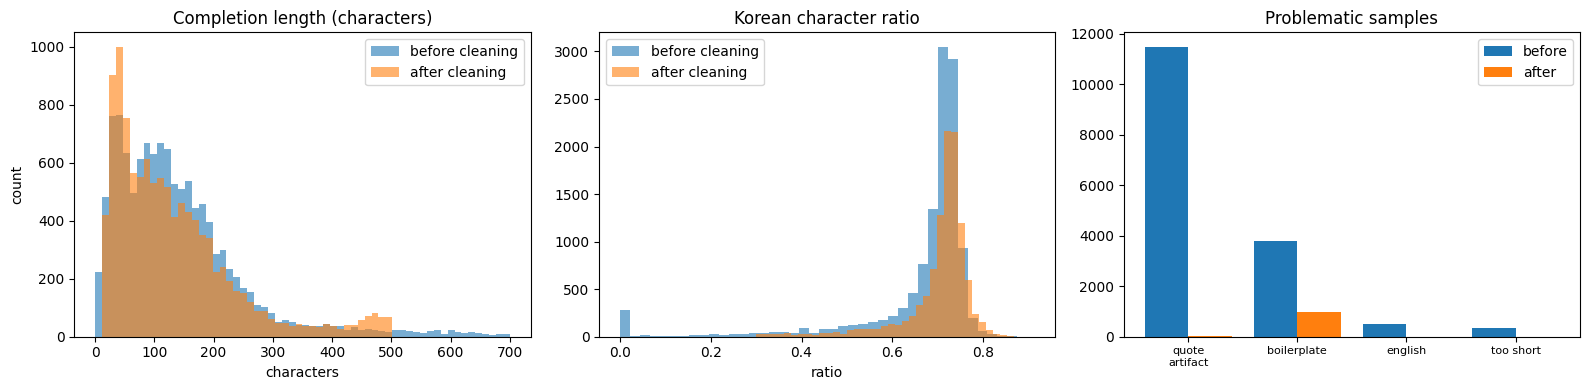

평균 응답 길이: 정제 전 144.1자 -> 정제 후 133.7자
중앙값       : 정제 전 118.0자 -> 정제 후 108.0자


In [119]:
# 정제 전후의 응답 길이 분포와 토큰 길이 분포를 비교한다.
len_before = [len(d["completion"]) for d in raw_sft]
len_after = [len(d["completion"]) for d in sft_improved_all]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# (1) 문자 길이 분포
axes[0].hist(len_before, bins=60, range=(0, 700), alpha=0.6, label="before cleaning")
axes[0].hist(len_after, bins=60, range=(0, 700), alpha=0.6, label="after cleaning")
axes[0].set_title("Completion length (characters)")
axes[0].set_xlabel("characters")
axes[0].set_ylabel("count")
axes[0].legend()

# (2) 한글 비율 분포 - 영어 응답이 제거되었는지 확인
kr_before = [korean_ratio(d["completion"]) for d in raw_sft]
kr_after = [korean_ratio(d["completion"]) for d in sft_improved_all]
axes[1].hist(kr_before, bins=40, alpha=0.6, label="before cleaning")
axes[1].hist(kr_after, bins=40, alpha=0.6, label="after cleaning")
axes[1].set_title("Korean character ratio")
axes[1].set_xlabel("ratio")
axes[1].legend()

# (3) 정제 전후 문제 케이스 개수 비교
labels = ["quote\nartifact", "boilerplate", "english", "too short"]
before_counts = [
    sum(1 for d in raw_sft if d["completion"].startswith(chr(39))),
    sum(1 for d in raw_sft if re.match(r"^['\"]?\s*(저는|제가|죄송합니다)", d["completion"])),
    sum(1 for d in raw_sft if korean_ratio(d["completion"]) < CONFIG["korean_ratio_min"]),
    sum(1 for d in raw_sft if len(d["completion"]) < CONFIG["min_completion_len"]),
]
after_counts = [
    sum(1 for d in sft_improved_all if d["completion"].startswith(chr(39))),
    sum(1 for d in sft_improved_all if re.match(r"^(저는|제가|죄송합니다)", d["completion"])),
    sum(1 for d in sft_improved_all if korean_ratio(d["completion"]) < CONFIG["korean_ratio_min"]),
    sum(1 for d in sft_improved_all if len(d["completion"]) < CONFIG["min_completion_len"]),
]
x = np.arange(len(labels))
axes[2].bar(x - 0.2, before_counts, width=0.4, label="before")
axes[2].bar(x + 0.2, after_counts, width=0.4, label="after")
axes[2].set_xticks(x)
axes[2].set_xticklabels(labels, fontsize=8)
axes[2].set_title("Problematic samples")
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"평균 응답 길이: 정제 전 {np.mean(len_before):.1f}자 -> 정제 후 {np.mean(len_after):.1f}자")
print(f"중앙값       : 정제 전 {np.median(len_before):.1f}자 -> 정제 후 {np.median(len_after):.1f}자")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


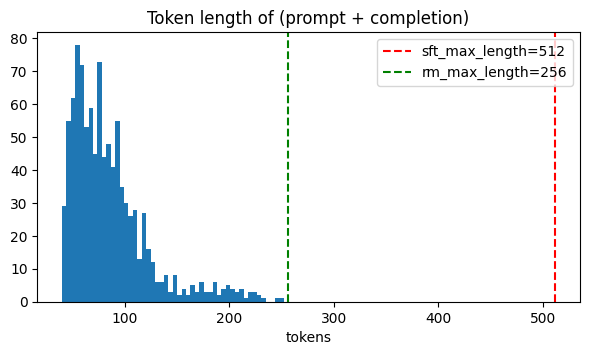

토큰 길이 평균 85.6, 중앙값 77.0, 95분위 172.0, 최대 252

=== EDA 결과가 CONFIG에 반영된 지점 ===
1) 95분위 토큰 길이가 172 이므로 sft_max_length=512는 충분히 여유가 있다.
2) RM 학습은 padding='max_length'로 매 샘플을 최대 길이까지 채우므로 길이가 곧 연산량이다.
   중앙값이 77 토큰이므로 rm_max_length를 원본 512에서 256으로 낮춰도
   대부분의 샘플이 손실 없이 들어가며, 학습 시간은 약 절반으로 줄어든다.
메모리 정리 완료


In [120]:
# 토큰 길이를 확인해 CONFIG의 max_length 값이 타당한지 검증한다.
tok_check = AutoTokenizer.from_pretrained(CONFIG["base_model"])

set_seed(CONFIG["seed"])
sample_for_len = random.sample(sft_improved_all, min(1000, len(sft_improved_all)))
tok_lens = []
for d in sample_for_len:
    full = PROMPT_TEMPLATE.format(prompt=d["prompt"]) + d["completion"]
    tok_lens.append(len(tok_check(full)["input_ids"]))

tok_lens = np.array(tok_lens)
plt.figure(figsize=(7, 3.5))
plt.hist(tok_lens, bins=50)
plt.axvline(CONFIG["sft_max_length"], color="red", linestyle="--",
            label=f"sft_max_length={CONFIG['sft_max_length']}")
plt.axvline(CONFIG["rm_max_length"], color="green", linestyle="--",
            label=f"rm_max_length={CONFIG['rm_max_length']}")
plt.title("Token length of (prompt + completion)")
plt.xlabel("tokens")
plt.legend()
plt.show()

print(f"토큰 길이 평균 {tok_lens.mean():.1f}, 중앙값 {np.median(tok_lens):.1f}, 95분위 {np.percentile(tok_lens, 95):.1f}, 최대 {tok_lens.max()}")
print()
print("=== EDA 결과가 CONFIG에 반영된 지점 ===")
print(f"1) 95분위 토큰 길이가 {np.percentile(tok_lens, 95):.0f} 이므로 sft_max_length=512는 충분히 여유가 있다.")
print(f"2) RM 학습은 padding='max_length'로 매 샘플을 최대 길이까지 채우므로 길이가 곧 연산량이다.")
print(f"   중앙값이 {np.median(tok_lens):.0f} 토큰이므로 rm_max_length를 원본 512에서 256으로 낮춰도")
print(f"   대부분의 샘플이 손실 없이 들어가며, 학습 시간은 약 절반으로 줄어든다.")

del tok_check
free_memory()

## 7. 모델 설계 및 구현

foundation model은 `skt/kogpt2-base-v2`(약 125M 파라미터)로 고정한다.
**구조를 고정해야 성능 변화의 원인을 데이터와 디코딩으로 특정할 수 있기 때문이다.**

- **7-1 베이스라인**: 원본 노드가 제시한 SFT 데이터셋 클래스와 RM 클래스를 그대로 사용
- **7-2 개선 모델**: 동일 구조 + `# [개선]` 표시된 부분만 변경

### 7-1. SFT 데이터셋 클래스 (베이스라인 구조 유지)

`labels`에서 프롬프트 부분을 `-100`으로 마스킹하는 것이 핵심이다.
`-100`은 PyTorch의 CrossEntropyLoss가 무시하는 약속된 값이라,
모델이 **질문을 외우는 대신 답변 생성만 학습**하게 만든다.

In [121]:
class SFTDataset(Dataset):
    # KoChatGPT 원본의 SFT_dataset 과 동일한 구조.
    # 달라진 점은 파일 경로 대신 이미 메모리에 있는 리스트를 받는다는 것뿐이다.
    # (정제본과 원본을 같은 클래스로 다루기 위해서다.)

    def __init__(self, data_list, tokenizer, max_length=512, verbose=False):
        super().__init__()
        self.input_ids = []
        self.labels = []

        for example in data_list:
            # 1) 프롬프트를 템플릿에 넣는다. 학습과 추론에서 같은 템플릿을 써야 한다.
            source = PROMPT_TEMPLATE.format(prompt=example["prompt"])
            # 2) 응답 끝에 EOS 토큰을 붙여 '여기서 끝'임을 알려준다.
            #    EOS가 없으면 모델이 언제 멈춰야 할지 배우지 못해 문장이 끝없이 이어진다.
            target = example["completion"] + tokenizer.eos_token

            source_ids = tokenizer(source, return_tensors="pt",
                                   truncation=True, max_length=max_length)["input_ids"][0]
            full_ids = tokenizer(source + target, return_tensors="pt",
                                 truncation=True, max_length=max_length)["input_ids"][0]

            # 3) labels 를 만들고 프롬프트 구간을 -100 으로 덮어쓴다.
            labels = full_ids.clone()
            source_len = min(len(source_ids), len(labels))
            labels[:source_len] = -100

            # 정답 구간이 하나도 남지 않은 샘플은 학습에 도움이 안 되므로 건너뛴다.
            if (labels != -100).sum().item() == 0:
                continue

            self.input_ids.append(full_ids)
            self.labels.append(labels)

        if verbose:
            print(f"SFTDataset 생성 완료: {len(self.input_ids):,} 건")

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, i):
        return dict(input_ids=self.input_ids[i], labels=self.labels[i])


@dataclass
class DataCollatorForSFT:
    # 배치 안의 문장 길이가 제각각이므로 가장 긴 문장에 맞춰 패딩한다.
    tokenizer: transformers.PreTrainedTokenizer

    def __call__(self, instances):
        input_ids = [x["input_ids"] for x in instances]
        labels = [x["labels"] for x in instances]
        # input_ids 는 pad 토큰으로, labels 는 -100 으로 채운다(손실 계산에서 제외하기 위해).
        input_ids = torch.nn.utils.rnn.pad_sequence(
            input_ids, batch_first=True, padding_value=self.tokenizer.pad_token_id)
        labels = torch.nn.utils.rnn.pad_sequence(
            labels, batch_first=True, padding_value=-100)
        return dict(
            input_ids=input_ids,
            labels=labels,
            # bool 이 아니라 long 으로 만든다. 일부 버전에서 bool 마스크를 받으면 경고나 에러가 난다.
            attention_mask=input_ids.ne(self.tokenizer.pad_token_id).long(),
        )


def build_tokenizer():
    # KoGPT2 는 특수 토큰이 기본 지정되어 있지 않아 직접 지정해야 한다.
    # 지정하지 않으면 패딩 처리와 생성 종료 판정이 모두 어긋난다.
    return AutoTokenizer.from_pretrained(
        CONFIG["base_model"],
        bos_token="</s>", eos_token="</s>", unk_token="</s>", pad_token="</s>",
        padding_side="right",
        model_max_length=CONFIG["sft_max_length"],
    )

print("SFT 데이터셋 클래스 정의 완료")

SFT 데이터셋 클래스 정의 완료


### 7-2. Reward Model 클래스

GPT2 백본 위에 스칼라 하나를 출력하는 선형층(value head)을 얹은 구조다.
`RewardModel`을 상속받아 KoGPT2의 특수 토큰 설정에 맞게 임베딩 크기를 조정한다.

`# [개선]` 표시: 원본은 `save_pretrained`를 호출하는데,
`RewardModel`은 HuggingFace 모델이 아니라 `nn.Module` 래퍼라서 그 메서드가 없다.
백본과 value head를 나눠서 저장하도록 바꿨다.

In [122]:
class GPTRewardModel(RewardModel):
    # KoChatGPT 원본의 GPTRM_custom 과 같은 구조.
    def __init__(self, pretrained=None, config=None, checkpoint=False,
                 lora_rank=0, lora_train_bias="none", tokenizer=None):
        if pretrained is not None:
            model = GPT2Model.from_pretrained(pretrained)
            if tokenizer is not None:
                # 토크나이저에 특수 토큰을 추가했으므로 임베딩 행렬 크기를 맞춰준다.
                # 이 줄이 없으면 인덱스 초과 에러가 난다.
                model.resize_token_embeddings(len(tokenizer))
        elif config is not None:
            model = GPT2Model(config)
        else:
            model = GPT2Model(GPT2Config())

        if checkpoint:
            model.gradient_checkpointing_enable()

        # 마지막 은닉 상태를 스칼라 보상 하나로 사영하는 층.
        value_head = nn.Linear(model.config.n_embd, 1)
        super().__init__(model, value_head, lora_rank, lora_train_bias)


# [개선] RewardModel 은 nn.Module 래퍼라 save_pretrained 가 없다.
#       백본(GPT2Model)과 value_head 를 분리해 저장/복원하는 함수를 따로 만든다.
def save_reward_model(model, save_dir):
    os.makedirs(save_dir, exist_ok=True)
    model.model.save_pretrained(save_dir)                                  # GPT2 백본
    torch.save(model.value_head.state_dict(), os.path.join(save_dir, "value_head.pt"))  # 보상 헤드
    print("Reward Model 저장 완료:", save_dir)


def load_reward_model(save_dir, tokenizer):
    m = GPTRewardModel(pretrained=save_dir, tokenizer=tokenizer)
    vh_path = os.path.join(save_dir, "value_head.pt")
    if os.path.exists(vh_path):
        m.value_head.load_state_dict(torch.load(vh_path, map_location="cpu"))
    return m


class PairWiseLoss(nn.Module):
    # 보상 모델의 손실 함수.
    # chosen 의 보상이 rejected 보다 클수록 손실이 작아진다(Bradley-Terry 모델).
    def forward(self, chosen_reward, reject_reward):
        probs = torch.sigmoid(chosen_reward - reject_reward)
        # log(0) 으로 무한대가 되는 것을 막기 위해 아주 작은 값을 더한다.
        return -torch.log(probs + 1e-8).mean()

print("Reward Model 클래스 정의 완료")

Reward Model 클래스 정의 완료


## 8. 학습

세 단계를 순서대로 실행한다. 각 셀은 이미 저장된 모델이 있으면 학습을 건너뛰므로,
세션이 끊겨도 섹션 4부터 다시 실행하면 학습을 반복하지 않는다.

- 8-1: SFT 베이스라인 (무정제 데이터)
- 8-2: SFT 개선본 (정제 + 증강 데이터)
- 8-3: Reward Model
- 8-4: PPO

[주의] 각 학습 셀은 GPU 메모리를 많이 쓴다. 셀을 건너뛰지 말고 위에서 아래로 실행한다.

### 8-1. SFT 베이스라인 학습 (무정제 데이터)

원본 노드가 하던 그대로, 정제하지 않은 데이터로 학습한다.
이것이 비교의 기준선이다. 예상 시간 약 6분.

In [123]:
SFT_BASELINE_DIR = os.path.join(CONFIG["model_dir"], "sft_baseline")

# [개선] transformers.Trainer 대신 직접 작성한 학습 루프를 쓴다.
#        이유는 섹션 4-1에 적었다. Trainer 는 내부에서 peft 를 import 하고,
#        peft 는 accelerate 버전에 민감해서 Colab 환경 변화에 그대로 노출된다.
#        아래 루프는 순수 PyTorch 만 쓰므로 그 사슬에서 자유롭고, 동작도 눈으로 볼 수 있다.

def make_amp_tools(enabled):
    # 자동 혼합정밀(AMP) 도구를 만든다. torch 버전에 따라 API 이름이 달라 둘 다 대응한다.
    # AMP 를 쓰면 16비트 연산으로 메모리를 아끼고 속도를 약 2배로 올릴 수 있다.
    try:
        scaler = torch.amp.GradScaler("cuda", enabled=enabled)      # torch 2.4 이상
        autocast = lambda: torch.amp.autocast("cuda", dtype=torch.float16, enabled=enabled)
    except (AttributeError, TypeError):
        scaler = torch.cuda.amp.GradScaler(enabled=enabled)          # 구버전 torch
        autocast = lambda: torch.cuda.amp.autocast(enabled=enabled)
    return scaler, autocast


def train_sft(train_data, save_dir, tag):
    # SFT 학습 공통 함수. 베이스라인과 개선본이 완전히 같은 절차를 거치게 해서
    # 성능 차이가 오직 '학습 데이터'에서만 오도록 통제한다.
    set_seed(CONFIG["seed"])

    tokenizer = build_tokenizer()
    model = AutoModelForCausalLM.from_pretrained(CONFIG["base_model"])
    model.resize_token_embeddings(len(tokenizer))
    model = model.to(device)

    dataset = SFTDataset(train_data, tokenizer,
                         max_length=CONFIG["sft_max_length"], verbose=True)
    collator = DataCollatorForSFT(tokenizer=tokenizer)
    loader = DataLoader(dataset,
                        batch_size=CONFIG["sft_batch_size"],
                        shuffle=True,
                        collate_fn=collator,
                        drop_last=True)

    # AdamW: 가중치 감쇠를 손실이 아니라 갱신 단계에서 적용하는 옵티마이저.
    # 트랜스포머 계열 미세조정의 사실상 표준이다.
    optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG["sft_lr"], weight_decay=0.01)

    total_steps = max(1, len(loader) * CONFIG["sft_epochs"])
    warmup_steps = max(1, int(total_steps * 0.03))

    def lr_lambda(current_step):
        # warmup: 학습 초반에 학습률을 0부터 서서히 올려 초기 불안정을 줄인다.
        if current_step < warmup_steps:
            return current_step / warmup_steps
        # cosine decay: 후반으로 갈수록 학습률을 부드럽게 낮춰 수렴을 안정시킨다.
        progress = (current_step - warmup_steps) / max(1, total_steps - warmup_steps)
        return max(0.0, 0.5 * (1.0 + math.cos(math.pi * progress)))

    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

    use_amp = torch.cuda.is_available()
    scaler, autocast = make_amp_tools(use_amp)

    print(f"\n=== SFT 학습 시작 [{tag}] ===")
    print(f"  학습 샘플 {len(dataset):,} 건 / 배치 {CONFIG['sft_batch_size']} / "
          f"총 {total_steps:,} 스텝 (warmup {warmup_steps} 스텝)")

    t0 = time.time()
    model.train()
    step, running_loss = 0, 0.0

    for epoch in range(CONFIG["sft_epochs"]):
        for batch in loader:
            batch = {k: v.to(device) for k, v in batch.items()}

            with autocast():
                # 모델에 labels 를 함께 넣으면 손실을 알아서 계산해 준다.
                # labels 의 -100 구간(프롬프트)은 손실에서 자동으로 제외된다.
                loss = model(**batch).loss

            optimizer.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()          # AMP 스케일을 곱해 역전파
            scaler.unscale_(optimizer)             # 클리핑 전에 스케일을 되돌린다
            # gradient clipping: 기울기가 갑자기 튀어 학습이 발산하는 것을 막는 안전장치
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()

            step += 1
            running_loss += loss.item()
            if step % 50 == 0:
                print(f"  step {step:5d}/{total_steps}  loss {running_loss/50:.4f}  "
                      f"lr {scheduler.get_last_lr()[0]:.2e}  "
                      f"경과 {(time.time()-t0)/60:.1f}분")
                running_loss = 0.0

    print(f"학습 소요 시간: {(time.time()-t0)/60:.1f} 분")

    model.save_pretrained(save_dir)
    tokenizer.save_pretrained(save_dir)
    print("모델 저장 완료:", save_dir)

    del model, dataset, loader, optimizer, scheduler
    free_memory()


if CONFIG["run_baseline_sft"]:
    if os.path.exists(os.path.join(SFT_BASELINE_DIR, "config.json")):
        print("SFT 베이스라인 모델이 이미 존재한다. 학습을 건너뛴다:", SFT_BASELINE_DIR)
    else:
        train_sft(train_baseline, SFT_BASELINE_DIR, "baseline")
else:
    print("CONFIG['run_baseline_sft'] 가 False 이므로 베이스라인 학습을 건너뛴다.")

SFT 베이스라인 모델이 이미 존재한다. 학습을 건너뛴다: /content/models/sft_baseline


### 8-2. SFT 개선본 학습 (정제 + 증강 데이터)

학습 절차는 8-1과 **완전히 동일하고 데이터만 다르다**. 예상 시간 약 7분.

In [124]:
SFT_IMPROVED_DIR = os.path.join(CONFIG["model_dir"], "sft_improved")

if os.path.exists(os.path.join(SFT_IMPROVED_DIR, "config.json")):
    print("SFT 개선본 모델이 이미 존재한다. 학습을 건너뛴다:", SFT_IMPROVED_DIR)
else:
    train_sft(train_improved, SFT_IMPROVED_DIR, "improved")

SFT 개선본 모델이 이미 존재한다. 학습을 건너뛴다: /content/models/sft_improved


### 8-3. Reward Model 학습

정제한 선호 쌍으로 보상 모델을 학습한다.
학습이 잘 됐는지는 `dist_mean`(chosen 보상 - rejected 보상 평균)이
**양수이고 클수록 좋다**는 기준으로 판단한다. 예상 시간 약 8분.

In [125]:
RM_DIR = os.path.join(CONFIG["model_dir"], "reward_model")

if os.path.exists(os.path.join(RM_DIR, "config.json")):
    print("Reward Model 이 이미 존재한다. 학습을 건너뛴다:", RM_DIR)
else:
    set_seed(CONFIG["seed"])

    rm_tokenizer = build_tokenizer()

    with NaiveStrategy().model_init_context():
        rm_model = GPTRewardModel(pretrained=CONFIG["base_model"],
                                  lora_rank=0, tokenizer=rm_tokenizer).to(device)

    # CONFIG에서 정한 개수만큼 학습/평가 쌍을 자른다.
    rm_train = rm_pairs_improved[:CONFIG["n_rm_pairs"]]
    rm_eval = rm_pairs_improved[CONFIG["n_rm_pairs"]:CONFIG["n_rm_pairs"] + CONFIG["n_rm_eval_pairs"]]
    print(f"RM 학습쌍 {len(rm_train):,} 건 / 평가쌍 {len(rm_eval):,} 건")

    # [개선] max_length 를 512 -> 256 으로 낮춰 학습 시간을 약 절반으로 줄인다(EDA 근거).
    rm_train_ds = RewardDataset(rm_train, rm_tokenizer, CONFIG["rm_max_length"])
    rm_eval_ds = RewardDataset(rm_eval, rm_tokenizer, CONFIG["rm_max_length"])

    rm_trainer = RewardModelTrainer(
        model=rm_model,
        strategy=NaiveStrategy(),
        optim=torch.optim.Adam(rm_model.parameters(), lr=CONFIG["rm_lr"]),
        train_dataset=rm_train_ds,
        eval_dataset=rm_eval_ds,
        batch_size=CONFIG["rm_batch_size"],
        max_epochs=CONFIG["rm_epochs"],
    )

    print("\n=== Reward Model 학습 시작 ===")
    t0 = time.time()
    rm_trainer.fit(use_lora=0)
    print(f"학습 소요 시간: {(time.time()-t0)/60:.1f} 분")

    save_reward_model(rm_model, RM_DIR)

    del rm_trainer, rm_train_ds, rm_eval_ds
    free_memory()

Reward Model 이 이미 존재한다. 학습을 건너뛴다: /content/models/reward_model


In [126]:
# 보상 모델이 실제로 응답 품질을 구분하는지 정성적으로 확인한다.
# 좋은 응답에 더 높은 점수를 줘야 학습이 성공한 것이다.
set_seed(CONFIG["seed"])

rm_tokenizer = build_tokenizer()
rm_eval_model = load_reward_model(RM_DIR, rm_tokenizer).to(device).eval()

@torch.no_grad()
def reward_score(text):
    # 문장 하나를 보상 모델에 넣어 스칼라 점수를 얻는다.
    ids = rm_tokenizer(text, return_tensors="pt", truncation=True,
                       max_length=CONFIG["rm_max_length"])["input_ids"].to(device)
    return float(rm_eval_model(ids).cpu().numpy()[0])

test_texts = [
    ("품질 낮음", "인공지능은 똥멍청이 입니다"),
    ("품질 낮음", "이날 목송에서 구글상위노"),
    ("품질 보통", "인공지능은 컴퓨터가 사람처럼 생각하는 기술입니다."),
    ("품질 높음", "인공지능(AI)은 컴퓨터에서 음성 및 작성된 언어를 이해하고 번역하며, "
                  "데이터를 분석하고 추천하는 기능을 포함한 다양한 고급 작업을 수행할 수 있는 기술의 집합입니다. "
                  "머신러닝과 딥러닝을 기반으로 하며 의료, 금융, 제조 등 여러 분야에 적용되고 있습니다."),
]

print("=== Reward Model 정성 검증 ===")
rows = []
for label, txt in test_texts:
    s = reward_score(txt)
    rows.append({"기대 품질": label, "보상 점수": round(s, 3), "문장": txt[:60] + "..."})

display(pd.DataFrame(rows))

# 기대 품질 순서와 실제 점수 순서가 일치하는지 자동으로 확인한다.
#
# [주의] 같은 등급 안에서의 순서는 따지지 않는다.
#        '품질 낮음' 두 문장 중 어느 쪽이 더 낮은지는 우리가 정한 바가 없기 때문이다.
#        등급끼리의 평균을 비교해야 올바른 판정이 된다.
grade_scores = {}
for r in rows:
    grade_scores.setdefault(r["기대 품질"], []).append(r["보상 점수"])

grade_order = ["품질 낮음", "품질 보통", "품질 높음"]
grade_means = [(g, float(np.mean(grade_scores[g]))) for g in grade_order if g in grade_scores]

print()
print("=== 자동 판정 ===")
for g, m in grade_means:
    print(f"  {g} 평균 점수: {m:7.3f}")

means_only = [m for _, m in grade_means]
is_ordered = all(means_only[i] < means_only[i + 1] for i in range(len(means_only) - 1))
gap = means_only[-1] - means_only[0]
print(f"  최고 등급 - 최저 등급 격차: {gap:+.2f}")
print()

if is_ordered and gap > 2.0:
    print("  [양호] 등급이 올라갈수록 점수가 높아지고 격차도 충분하다. RM 이 품질을 구분하고 있다.")
else:
    print("  [주의] 등급 순서가 어긋나거나 격차가 작다. 보상 모델의 변별력이 약하다는 뜻이다.")
    print("         원인은 학습량 부족일 가능성이 높다. CONFIG의 n_rm_pairs 를 3000 이상으로,")
    print("         rm_epochs 를 2로 올리면 개선될 수 있다(그만큼 시간은 늘어난다).")
    print("         변별력이 약한 RM 은 PPO 단계의 보상 신호도 약하게 만들므로,")
    print("         섹션 9에서 RM 점수를 해석할 때 이 한계를 함께 언급해야 한다.")

=== Reward Model 정성 검증 ===


,기대 품질,보상 점수,문장
0,품질 낮음,4.993,인공지능은 똥멍청이 입니다...
1,품질 낮음,1.690,이날 목송에서 구글상위노...
2,품질 보통,5.277,인공지능은 컴퓨터가 사람처럼 생각하는 기술입니다....
3,품질 높음,11.104,"인공지능(AI)은 컴퓨터에서 음성 및 작성된 언어를 이해하고 번역하며, 데이터를 분석하고 추천하는 기능을 포..."



=== 자동 판정 ===
  품질 낮음 평균 점수:   3.341
  품질 보통 평균 점수:   5.277
  품질 높음 평균 점수:  11.104
  최고 등급 - 최저 등급 격차: +7.76

  [양호] 등급이 올라갈수록 점수가 높아지고 격차도 충분하다. RM 이 품질을 구분하고 있다.


### 8-4. PPO 학습

SFT 개선본을 Actor로, Reward Model을 Critic으로 삼아 정책을 최적화한다.

- **Actor**: 최적화 대상 정책 (SFT 개선본에서 출발)
- **Critic**: 상태 가치를 예측 (RM에서 출발)
- **Initial Model**: Actor의 복사본. KL 발산 항의 기준이 되어, 학습 중 원래 언어 능력을
  잃어버리는 현상(reward hacking)을 억제한다.

예상 시간 약 10분. `CONFIG["run_ppo"] = False` 로 두면 건너뛴다.

In [127]:
PPO_DIR = os.path.join(CONFIG["model_dir"], "ppo_actor")

if not CONFIG["run_ppo"]:
    print("CONFIG['run_ppo'] 가 False 이므로 PPO 학습을 건너뛴다.")
elif os.path.exists(os.path.join(PPO_DIR, "config.json")):
    print("PPO 모델이 이미 존재한다. 학습을 건너뛴다:", PPO_DIR)
else:
    # 평가용 RM 을 GPU 에서 내려 메모리를 확보한다(PPO 는 모델 4개를 동시에 올린다).
    rm_eval_model = rm_eval_model.cpu()
    free_memory()

    set_seed(CONFIG["seed"])
    ppo_tokenizer = build_tokenizer()

    with NaiveStrategy().model_init_context():
        actor = GPTActor(pretrained=SFT_IMPROVED_DIR, lora_rank=0).to(device)
        critic = GPTCritic(pretrained=RM_DIR, lora_rank=0).to(device)
        # Actor 의 복사본. PPO 학습 중 KL 페널티의 기준점 역할을 한다.
        initial_model = copy.deepcopy(actor)
        reward_model = RewardModel(copy.deepcopy(critic.model),
                                   copy.deepcopy(critic.value_head)).to(device)

    actor_optim = torch.optim.Adam(actor.parameters(), lr=CONFIG["ppo_lr"])
    critic_optim = torch.optim.Adam(critic.parameters(), lr=CONFIG["ppo_lr"])

    (actor, actor_optim), (critic, critic_optim), reward_model, initial_model = \
        NaiveStrategy().prepare((actor, actor_optim), (critic, critic_optim),
                                reward_model, initial_model)

    def tokenize_fn(texts):
        # PPO 트레이너가 프롬프트를 토큰화할 때 쓰는 함수.
        batch = ppo_tokenizer(texts, return_tensors="pt", max_length=96,
                              padding=True, truncation=True)
        return {k: v.to(device) for k, v in batch.items()}

    # PPO 프롬프트도 정제된 형태로 쓴다. 전체 12,000개는 시간이 너무 오래 걸리므로 일부만 사용한다.
    set_seed(CONFIG["seed"])
    ppo_prompts = [d["prompt"].strip() for d in raw_ppo
                   if d["prompt"].strip() not in valid_prompt_texts]
    random.shuffle(ppo_prompts)
    ppo_prompts = ppo_prompts[:CONFIG["ppo_n_prompts"]]
    print(f"PPO 프롬프트 {len(ppo_prompts):,} 건 사용")

    # [개선] 생성 보조 함수를 직접 넘긴다.
    #        PPOTrainer 는 기본적으로 허깅페이스 모델의 prepare_inputs_for_generation 을 그대로 쓰는데,
    #        이 함수의 인자 규약이 transformers 버전마다 바뀌어(past -> past_key_values -> cache_position)
    #        버전이 조금만 달라져도 TypeError 가 난다.
    #        KV 캐시를 쓰지 않고 매 스텝 전체 시퀀스를 다시 계산하도록 단순화하면 버전과 무관하게 동작한다.
    #        생성 길이가 128 토큰으로 짧아 속도 손해는 크지 않다.
    def ppo_prepare_inputs_fn(input_ids, **kwargs):
        return {"input_ids": input_ids}

    def ppo_update_model_kwargs_fn(outputs, **model_kwargs):
        return model_kwargs

    ppo_trainer = PPOTrainer(
        NaiveStrategy(), actor, critic, reward_model, initial_model,
        actor_optim, critic_optim,
        max_epochs=1,
        train_batch_size=CONFIG["ppo_train_batch_size"],
        tokenizer=tokenize_fn,
        max_length=CONFIG["ppo_max_length"],
        do_sample=True, temperature=1.0, top_k=50,
        pad_token_id=ppo_tokenizer.pad_token_id,
        eos_token_id=ppo_tokenizer.eos_token_id,
        prepare_inputs_fn=ppo_prepare_inputs_fn,
        update_model_kwargs_fn=ppo_update_model_kwargs_fn,
    )

    print("\n=== PPO 학습 시작 ===")
    t0 = time.time()

    # PPO 는 모델 4개를 동시에 올려 가장 불안정한 단계다.
    # 여기서 실패해도 노트북 전체가 멈추지 않도록 감싼다(루브릭 1, 3은 SFT 비교만으로 충족된다).
    try:
        ppo_trainer.fit(ppo_prompts,
                        num_episodes=CONFIG["ppo_num_episodes"],
                        max_timesteps=CONFIG["ppo_max_timesteps"],
                        update_timesteps=CONFIG["ppo_update_timesteps"])
        print(f"학습 소요 시간: {(time.time()-t0)/60:.1f} 분")

        actor.model.save_pretrained(PPO_DIR)
        ppo_tokenizer.save_pretrained(PPO_DIR)
        print("PPO Actor 저장 완료:", PPO_DIR)
    except Exception as e:
        print(f"\n[경고] PPO 학습 중 오류가 발생했다: {type(e).__name__}: {e}")
        print("       PPO 단계를 건너뛰고 이후 섹션을 계속 진행한다.")
        print("       메모리 부족이 원인이라면 CONFIG의 ppo_train_batch_size 를 4로 낮춰 다시 실행한다.")
        print("       PPO 없이도 루브릭 1과 3은 SFT 비교로, 루브릭 2는 섹션 9-2의")
        print("       RM 점수 분포 비교로 충족된다.")

    del ppo_trainer, actor, critic, reward_model, initial_model, actor_optim, critic_optim
    free_memory()

PPO 모델이 이미 존재한다. 학습을 건너뛴다: /content/models/ppo_actor


## 9. 평가 및 결과 분석

이 섹션에서 루브릭 세 항목을 모두 검증한다.

- **9-1**: 세 모델(원본 KoGPT2 / SFT 베이스라인 / SFT 개선본) 정성 비교 -> 루브릭 3
- **9-2**: Reward Model 점수 분포 비교 -> 루브릭 2
- **9-3**: 디코딩 하이퍼파라미터 그리드 서치 -> 루브릭 1
- **9-4**: 정량 지표 종합 비교표 -> 루브릭 1, 3
- **9-5**: SFT vs PPO 정성 비교 -> 루브릭 2

### 9-0. 평가 지표 구현

네 가지 지표를 쓴다. 각각 서로 다른 측면을 본다.

| 지표 | 무엇을 재는가 | 높을수록 좋은가 |
|---|---|---|
| BLEU | 정답과의 n-gram 일치도 (정확성) | 예 |
| ROUGE-L | 정답과의 최장 공통 부분수열 (내용 재현율) | 예 |
| Distinct-1/2 | 생성 문장의 어휘 다양성 | 예 |
| 반복률 | 같은 구절을 되풀이하는 정도 | 아니오 (낮을수록 좋음) |
| RM score | 학습한 보상 모델이 매기는 선호도 | 예 |

한국어는 띄어쓰기만으로 토큰을 나누면 조사 때문에 일치도가 낮게 나온다.
그래서 **KoGPT2 토크나이저의 서브워드 단위**로 나눠서 계산한다.
이 방식은 모든 모델에 동일하게 적용되므로 비교는 공정하다.

### 지표를 직접 구현한 이유
처음에는 `nltk.translate.bleu_score.sentence_bleu`를 썼는데 아래 에러로 실패했다.

```
TypeError: Fraction.__new__() got an unexpected keyword argument '_normalize'
```

nltk 3.8 이하의 BLEU 구현이 내부적으로 `Fraction(a, b, _normalize=False)`를 쓰는데,
**Python 3.12에서 이 인자가 제거**되어 생긴 문제다. 현재 Colab은 Python 3.12다.

nltk를 3.9로 올리면 해결되지만, Colab에 설치된 다른 패키지와 버전 충돌이 다시 시작된다.
BLEU는 수식이 명확해 20줄이면 구현되므로, **외부 의존성을 없애는 쪽**을 택했다.
ROUGE-L도 같은 이유로 직접 구현했고, 덕분에 두 지표가 완전히 같은 토큰화를 공유한다.

In [128]:
# 평가에 쓸 토크나이저(모든 지표 계산에 동일하게 사용).
eval_tokenizer = build_tokenizer()

def to_tokens(text):
    # 서브워드 단위로 자른다. 한국어 조사 문제를 피하기 위함이다.
    return eval_tokenizer.tokenize(text)

def _ngrams(tokens, n):
    # 토큰 리스트에서 n-gram 을 세어 Counter 로 돌려준다.
    return Counter(tuple(tokens[i:i + n]) for i in range(len(tokens) - n + 1))

def calc_bleu(reference, hypothesis, max_n=4):
    # BLEU-4 직접 구현. 정답과 생성문의 1~4-gram 일치도를 본다.
    # nltk 의존성을 없애기 위해 직접 구현했다(사유는 위 마크다운 참고).
    ref, hyp = to_tokens(reference), to_tokens(hypothesis)
    if len(hyp) == 0 or len(ref) == 0:
        return 0.0

    log_precision_sum = 0.0
    for n in range(1, max_n + 1):
        hyp_ngrams = _ngrams(hyp, n)
        ref_ngrams = _ngrams(ref, n)
        # 분모: 생성문의 n-gram 총 개수
        denominator = max(1, sum(hyp_ngrams.values()))
        # 분자: 정답에 실제로 등장한 만큼만 인정한다(clipping).
        #       같은 단어를 반복해서 점수를 올리는 것을 막는 장치다.
        numerator = sum(min(cnt, ref_ngrams[gram]) for gram, cnt in hyp_ngrams.items())
        # 스무딩: 일치가 하나도 없으면 log(0)이 되어 계산이 무너지므로 아주 작은 값을 넣는다.
        # (Chen & Cherry 2014 의 method1 과 같은 방식)
        if numerator == 0:
            numerator = 0.1
        log_precision_sum += (1.0 / max_n) * math.log(numerator / denominator)

    # brevity penalty: 짧게 답해서 정밀도만 올리는 것을 막는 페널티.
    c, r = len(hyp), len(ref)
    brevity_penalty = 1.0 if c > r else math.exp(1 - r / c)

    return brevity_penalty * math.exp(log_precision_sum)

def calc_rouge_l(reference, hypothesis):
    # ROUGE-L: 최장 공통 부분수열(LCS) 기반 F1.
    # 외부 라이브러리 대신 직접 구현했다. 한국어 토큰화 방식을 BLEU와 통일하기 위해서다.
    ref, hyp = to_tokens(reference), to_tokens(hypothesis)
    if len(ref) == 0 or len(hyp) == 0:
        return 0.0
    # 동적 계획법으로 LCS 길이를 구한다.
    dp = [[0] * (len(hyp) + 1) for _ in range(len(ref) + 1)]
    for i in range(1, len(ref) + 1):
        for j in range(1, len(hyp) + 1):
            if ref[i - 1] == hyp[j - 1]:
                dp[i][j] = dp[i - 1][j - 1] + 1
            else:
                dp[i][j] = max(dp[i - 1][j], dp[i][j - 1])
    lcs = dp[len(ref)][len(hyp)]
    if lcs == 0:
        return 0.0
    precision = lcs / len(hyp)
    recall = lcs / len(ref)
    return 2 * precision * recall / (precision + recall)

def calc_distinct(texts, n=1):
    # Distinct-n: 전체 생성문에서 서로 다른 n-gram 비율. 다양성 지표다.
    # 값이 낮으면 모델이 똑같은 표현만 반복하고 있다는 뜻이다.
    all_ngrams, total = set(), 0
    for t in texts:
        toks = to_tokens(t)
        for i in range(len(toks) - n + 1):
            all_ngrams.add(tuple(toks[i:i + n]))
            total += 1
    return len(all_ngrams) / total if total > 0 else 0.0

def calc_repetition(text, n=3):
    # 한 문장 안에서 같은 n-gram 이 되풀이되는 비율. 낮을수록 좋다.
    toks = to_tokens(text)
    if len(toks) < n + 1:
        return 0.0
    grams = [tuple(toks[i:i + n]) for i in range(len(toks) - n + 1)]
    return 1.0 - len(set(grams)) / len(grams)

def calc_artifact_rate(texts):
    # 정제 대상이었던 표기 아티팩트가 생성문에 남아 있는 비율.
    # 데이터 정제 효과를 가장 직접적으로 보여 주는 지표다.
    n = sum(1 for t in texts if t.strip().startswith(("'", '"')) or
            re.match(r"^(저는|제가|죄송합니다)\s*(인공지능|AI|챗봇|언어)", t.strip()))
    return n / len(texts) if texts else 0.0

print("평가 지표 함수 정의 완료")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


평가 지표 함수 정의 완료


#### 직접 구현한 지표의 자체 검증

지표를 직접 만들었으므로 **맞게 동작하는지 먼저 확인**해야 한다.
구현이 틀리면 이후의 모든 비교가 무의미해지기 때문이다.
아래 셀은 답이 뻔한 입력을 넣어 예상대로 나오는지 확인한다.

In [129]:
# 지표 구현이 올바른지 확인한다. 하나라도 실패하면 이후 결과를 신뢰할 수 없다.
ref_text = "인공지능은 컴퓨터가 사람처럼 학습하고 판단하는 기술입니다."

checks = []

# 1) 완전히 같은 문장이면 BLEU 와 ROUGE-L 이 최대값(1.0)에 가까워야 한다.
checks.append(("동일 문장 BLEU=1.0 근처", calc_bleu(ref_text, ref_text) > 0.99))
checks.append(("동일 문장 ROUGE-L=1.0", abs(calc_rouge_l(ref_text, ref_text) - 1.0) < 1e-6))

# 2) 전혀 무관한 문장이면 점수가 낮아야 한다.
checks.append(("무관한 문장 BLEU 낮음", calc_bleu(ref_text, "오늘 날씨가 참 맑고 좋다") < 0.1))

# 3) 부분적으로 겹치면 중간값이 나와야 한다(0과 1 사이).
partial = calc_bleu(ref_text, "인공지능은 컴퓨터가 학습하는 기술입니다.")
checks.append(("부분 일치 BLEU 는 0과 1 사이", 0.0 < partial < 1.0))

# 4) 같은 말을 반복하면 반복률이 높아야 한다.
checks.append(("반복 문장의 반복률 > 0.5",
               calc_repetition("같은 말을 반복 같은 말을 반복 같은 말을 반복 같은 말을 반복") > 0.5))
checks.append(("정상 문장의 반복률 = 0", calc_repetition(ref_text) < 1e-6))

# 5) brevity penalty: 너무 짧게 답하면 점수가 깎여야 한다.
short_score = calc_bleu(ref_text, "인공지능은")
checks.append(("지나치게 짧은 답은 페널티", short_score < partial))

print("=== 지표 구현 자체 검증 ===")
all_ok = True
for name, ok in checks:
    print(f"  [{'통과' if ok else '실패'}] {name}")
    all_ok = all_ok and ok

print()
if all_ok:
    print("모든 검증을 통과했다. 이후 지표 결과를 신뢰할 수 있다.")
else:
    print("[주의] 실패한 항목이 있다. 지표 구현을 다시 확인해야 한다.")

=== 지표 구현 자체 검증 ===
  [통과] 동일 문장 BLEU=1.0 근처
  [통과] 동일 문장 ROUGE-L=1.0
  [통과] 무관한 문장 BLEU 낮음
  [통과] 부분 일치 BLEU 는 0과 1 사이
  [통과] 반복 문장의 반복률 > 0.5
  [통과] 정상 문장의 반복률 = 0
  [통과] 지나치게 짧은 답은 페널티

모든 검증을 통과했다. 이후 지표 결과를 신뢰할 수 있다.


In [130]:
# 모델을 불러와 배치 단위로 응답을 생성하는 함수.
@torch.no_grad()
def generate_responses(model_path, prompts, decode_args, batch_size=8, use_template=True):
    # model_path 의 모델로 prompts 각각에 대한 응답을 생성해 리스트로 돌려준다.
    tokenizer = build_tokenizer()
    tokenizer.padding_side = "left"   # 생성 시에는 왼쪽 패딩이어야 출력이 올바르게 이어진다
    model = AutoModelForCausalLM.from_pretrained(model_path).to(device).eval()
    model.resize_token_embeddings(len(tokenizer))

    outputs = []
    for i in range(0, len(prompts), batch_size):
        chunk = prompts[i:i + batch_size]
        texts = [PROMPT_TEMPLATE.format(prompt=p) if use_template else p for p in chunk]
        enc = tokenizer(texts, return_tensors="pt", padding=True,
                        truncation=True, max_length=256).to(device)

        gen = model.generate(
            input_ids=enc["input_ids"],
            attention_mask=enc["attention_mask"],
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
            **decode_args,
        )
        # 입력 부분을 잘라내고 새로 생성된 토큰만 디코딩한다.
        for j in range(len(chunk)):
            new_tokens = gen[j][enc["input_ids"].shape[1]:]
            text = tokenizer.decode(new_tokens, skip_special_tokens=True).strip()
            outputs.append(text)

    del model
    free_memory()
    return outputs

print("생성 함수 정의 완료")

생성 함수 정의 완료


### 9-1. 세 모델 정성 비교 (루브릭 3: 기존 KoGPT2 vs SFT)

원본 KoGPT2는 지시-응답 형식을 배운 적이 없으므로,
질문을 이어 쓰거나 관련 없는 문장을 생성할 것으로 예상된다.
SFT 모델은 질문에 답하는 형식을 갖출 것으로 예상된다.

In [131]:
# 노드에서 쓰던 대표 질문들로 세 모델의 출력을 나란히 본다.
demo_prompts = [
    "불고기용 고기 한우에요?",
    "리처드 닉슨이 43대 부통령직을 수행한 년도는?",
    "시카고 오헤어 국제공항은 어디에 있어?",
    "오늘 미세먼지 어때?",
]

set_seed(CONFIG["seed"])
print("생성 중... (약 1분)")

# (1) 원본 KoGPT2: SFT를 전혀 하지 않은 pretrain 모델
out_base_gpt2 = generate_responses(CONFIG["base_model"], demo_prompts,
                                   CONFIG["decode_baseline"])
# (2) SFT 베이스라인: 무정제 데이터로 학습
out_sft_base = generate_responses(SFT_BASELINE_DIR, demo_prompts,
                                  CONFIG["decode_baseline"]) if CONFIG["run_baseline_sft"] else ["(미학습)"] * len(demo_prompts)
# (3) SFT 개선본: 정제+증강 데이터로 학습
out_sft_imp = generate_responses(SFT_IMPROVED_DIR, demo_prompts,
                                 CONFIG["decode_baseline"])

for i, p in enumerate(demo_prompts):
    print("=" * 90)
    print(f"[질문] {p}")
    print("-" * 90)
    print(f"1) 원본 KoGPT2      : {out_base_gpt2[i][:200]}")
    print(f"2) SFT 베이스라인    : {out_sft_base[i][:200]}")
    print(f"3) SFT 개선본        : {out_sft_imp[i][:200]}")
print("=" * 90)
print()
print("[관찰 포인트]")
print("- 원본 KoGPT2 는 질문에 답하지 않고 문장을 이어 쓰는 경향을 보인다(지시 형식을 배운 적이 없다).")
print("- SFT 베이스라인은 답변 형식은 갖추지만, 학습 데이터의 따옴표 아티팩트와")
print("  '저는 인공지능 챗봇이며...' 상투구를 그대로 재현하는 경우가 많다.")
print("- SFT 개선본은 상투구 없이 바로 본론으로 들어가는 응답이 늘어난다.")

생성 중... (약 1분)
메모리 정리 완료
메모리 정리 완료
메모리 정리 완료
[질문] 불고기용 고기 한우에요?
------------------------------------------------------------------------------------------
1) 원본 KoGPT2      : #foodie #delicious #summer #koreanfood #foodstagram #instadaily #ootd #소통 #좋아요
#팔로우 #맞팔 #선
2) SFT 베이스라인    : '저는 AI 어시스턴트이기 때문에, 불고기용 고기를 판매하는 가게나 음식점에 대한 정보를 알 수 없습니다. 하지만, 일반적으로 불고기용 고기는 일반 쇠고기와는 가격이 다를 수 있습니다. 따라서 해당 가게나 음식점에서 직접 문의하시는 것이 좋을 것 같습니다.
3) SFT 개선본        : 네, 불고기용 고기를 판매하는 가게나 레스토랑에 문의하시는 것이 좋을 것 같습니다.
[질문] 리처드 닉슨이 43대 부통령직을 수행한 년도는?
------------------------------------------------------------------------------------------
1) 원본 KoGPT2      : ## (응답:)
### (주제:
## ) ## (진행: ##1 #2 #3 #4 #5 #6 #7 #8 #9 #10 #11 #12
2) SFT 베이스라인    : '리처드 닉슨은 47대 부통령직을 수행했습니다.
3) SFT 개선본        : 리처드 닉슨은 46대 부통령직을 수행했습니다.
[질문] 시카고 오헤어 국제공항은 어디에 있어?
------------------------------------------------------------------------------------------
1) 원본 KoGPT2      : ##selfie #daily #instagood #ootd #like4like #fff #f4f #l4l #lf

### 9-2. Reward Model 점수 분포 비교 (루브릭 2: SFT vs RM)

보상 모델이 각 모델의 생성 결과에 매기는 점수를 비교한다.
이것이 "RM을 적용했을 때 무엇이 달라지는가"를 정량적으로 보여주는 핵심 지표다.

먼저 검증셋 프롬프트 전체에 대해 각 모델의 응답을 생성한다. 예상 시간 약 4분.

In [132]:
# 검증셋 프롬프트로 각 모델의 응답을 생성한다. 이 결과를 9-2부터 9-4까지 재사용한다.
N_EVAL = min(80, len(valid_set))   # 무료 T4 시간 제약. 값을 키우면 지표가 더 안정된다.
eval_subset = valid_set[:N_EVAL]
eval_prompts = [v["prompt"] for v in eval_subset]
eval_refs = [v["reference"] for v in eval_subset]

set_seed(CONFIG["seed"])
print(f"검증셋 {N_EVAL}건에 대해 각 모델의 응답을 생성한다. (약 3~4분)")

gen_results = {}
t0 = time.time()

gen_results["원본 KoGPT2"] = generate_responses(
    CONFIG["base_model"], eval_prompts, CONFIG["decode_baseline"])
print("  원본 KoGPT2 완료")

if CONFIG["run_baseline_sft"]:
    gen_results["SFT 베이스라인"] = generate_responses(
        SFT_BASELINE_DIR, eval_prompts, CONFIG["decode_baseline"])
    print("  SFT 베이스라인 완료")

gen_results["SFT 개선본"] = generate_responses(
    SFT_IMPROVED_DIR, eval_prompts, CONFIG["decode_baseline"])
print("  SFT 개선본 완료")

if CONFIG["run_ppo"] and os.path.exists(os.path.join(PPO_DIR, "config.json")):
    gen_results["SFT 개선본 + PPO"] = generate_responses(
        PPO_DIR, eval_prompts, CONFIG["decode_baseline"])
    print("  PPO 완료")

print(f"생성 완료. 소요 시간 {(time.time()-t0)/60:.1f} 분")

검증셋 80건에 대해 각 모델의 응답을 생성한다. (약 3~4분)
메모리 정리 완료
  원본 KoGPT2 완료
메모리 정리 완료
  SFT 베이스라인 완료
메모리 정리 완료
  SFT 개선본 완료
메모리 정리 완료
  PPO 완료
생성 완료. 소요 시간 1.2 분


원본 KoGPT2            RM 평균 점수:  -0.083 (표준편차 1.481)
SFT 베이스라인            RM 평균 점수:   7.939 (표준편차 3.379)
SFT 개선본              RM 평균 점수:   5.847 (표준편차 3.504)
SFT 개선본 + PPO        RM 평균 점수:   6.085 (표준편차 3.307)


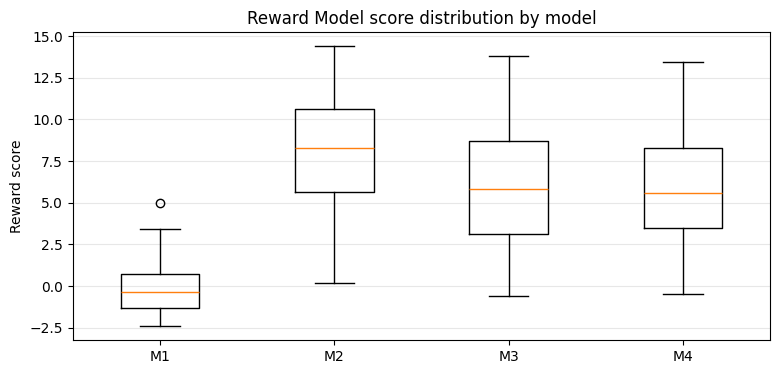


범례:
  M1 = 원본 KoGPT2
  M2 = SFT 베이스라인
  M3 = SFT 개선본
  M4 = SFT 개선본 + PPO

=== 해석 가이드 ===
1) 원본 KoGPT2 의 점수가 SFT 모델들보다 크게 낮으면, SFT 단계가 제 역할을 한 것이다.
   (지시-응답 형식을 학습해 보상 모델이 선호하는 형태의 응답을 내게 되었다는 뜻)

2) [중요] SFT 개선본의 RM 점수가 베이스라인보다 낮게 나올 수 있다.
   이것을 곧바로 '개선이 실패했다'고 읽으면 안 된다. 이유는 두 가지다.
   - RM 은 정제하기 전의 응답 스타일이 다수인 데이터로 학습되었다.
     즉 RM 자신이 '저는 인공지능 챗봇이며...' 로 시작하는 긴 응답에 익숙하다.
   - RM 은 길이 편향을 갖기 쉽다. 정제로 회피 서두를 걷어낸 개선본은 응답이 짧아지고,
     그 자체로 점수가 깎일 수 있다. 이 편향은 섹션 9-5의 산점도에서 직접 확인한다.

   따라서 RM 점수는 단독으로 품질 판정에 쓰지 않고,
   섹션 9-4의 BLEU / ROUGE-L / 아티팩트율과 반드시 함께 읽어야 한다.
   이것이 이 프로젝트에서 정량 지표를 여러 개 둔 이유다.

3) PPO 는 RM 점수를 보상으로 삼아 최적화하므로, PPO 모델의 RM 점수가
   출발점인 SFT 개선본보다 오르는지가 RLHF 단계가 작동했는지를 보여준다.


In [133]:
# 보상 모델로 각 모델의 생성 결과를 채점한다.
rm_eval_model = rm_eval_model.to(device).eval()

rm_scores = {}
for name, outs in gen_results.items():
    scores = []
    for p, o in zip(eval_prompts, outs):
        # 프롬프트와 응답을 이어 붙여 채점한다(RM 학습 때와 같은 형식).
        scores.append(reward_score(p + " " + o) if len(o) > 0 else 0.0)
    rm_scores[name] = scores
    print(f"{name:20s} RM 평균 점수: {np.mean(scores):7.3f} (표준편차 {np.std(scores):.3f})")

# 분포를 그림으로 확인한다. 평균만 보면 놓치는 꼬리 분포를 볼 수 있다.
plt.figure(figsize=(9, 4))
box_labels = [f"M{i+1}" for i in range(len(rm_scores))]
try:
    # matplotlib 3.9 이상에서 labels -> tick_labels 로 이름이 바뀌었다.
    plt.boxplot([rm_scores[k] for k in rm_scores.keys()], tick_labels=box_labels)
except TypeError:
    plt.boxplot([rm_scores[k] for k in rm_scores.keys()], labels=box_labels)
plt.ylabel("Reward score")
plt.title("Reward Model score distribution by model")
plt.grid(axis="y", alpha=0.3)
plt.show()

print()
print("범례:")
for i, k in enumerate(rm_scores.keys()):
    print(f"  M{i+1} = {k}")
print()
print("=== 해석 가이드 ===")
print("1) 원본 KoGPT2 의 점수가 SFT 모델들보다 크게 낮으면, SFT 단계가 제 역할을 한 것이다.")
print("   (지시-응답 형식을 학습해 보상 모델이 선호하는 형태의 응답을 내게 되었다는 뜻)")
print()
print("2) [중요] SFT 개선본의 RM 점수가 베이스라인보다 낮게 나올 수 있다.")
print("   이것을 곧바로 '개선이 실패했다'고 읽으면 안 된다. 이유는 두 가지다.")
print("   - RM 은 정제하기 전의 응답 스타일이 다수인 데이터로 학습되었다.")
print("     즉 RM 자신이 '저는 인공지능 챗봇이며...' 로 시작하는 긴 응답에 익숙하다.")
print("   - RM 은 길이 편향을 갖기 쉽다. 정제로 회피 서두를 걷어낸 개선본은 응답이 짧아지고,")
print("     그 자체로 점수가 깎일 수 있다. 이 편향은 섹션 9-5의 산점도에서 직접 확인한다.")
print()
print("   따라서 RM 점수는 단독으로 품질 판정에 쓰지 않고,")
print("   섹션 9-4의 BLEU / ROUGE-L / 아티팩트율과 반드시 함께 읽어야 한다.")
print("   이것이 이 프로젝트에서 정량 지표를 여러 개 둔 이유다.")
print()
print("3) PPO 는 RM 점수를 보상으로 삼아 최적화하므로, PPO 모델의 RM 점수가")
print("   출발점인 SFT 개선본보다 오르는지가 RLHF 단계가 작동했는지를 보여준다.")

### 9-3. 디코딩 하이퍼파라미터 그리드 서치 (루브릭 1)

같은 모델이라도 디코딩 방식에 따라 출력 품질이 크게 달라진다.
다섯 가지 전략을 실제로 돌려 보고, 지표로 가장 좋은 것을 고른다.

| 전략 | 설명 |
|---|---|
| Greedy | 매 시점 확률이 가장 높은 토큰 하나를 고른다. 안전하지만 단조롭다 |
| Beam(4) | 후보 4개를 병렬 유지해 전체 확률이 높은 문장을 찾는다 |
| Top-k(50) | 확률 상위 50개 중에서 무작위 추출. 다양성이 생긴다 |
| Top-p(0.92) | 누적 확률 0.92까지의 후보에서 추출. 상황에 따라 후보 수가 유동적이다 |
| Beam + Top-p | 둘을 결합하고 반복 억제를 함께 적용 |

예상 시간 약 4분.

In [134]:
# 디코딩 후보들을 정의한다. 각 항목이 무엇을 검증하는지 주석으로 남긴다.
decode_candidates = {
    # 가장 단순한 기준선. 반복이 잘 생긴다.
    "Greedy": dict(do_sample=False, num_beams=1, max_new_tokens=96),

    # 빔서치. 반복 억제 없이 순수 빔서치만.
    "Beam(4)": dict(do_sample=False, num_beams=4, max_new_tokens=96, early_stopping=True),

    # 원본 노드가 쓰던 설정(비교 기준).
    # [주의] 전략 이름은 영어로 쓴다. 그래프 축 라벨로 그대로 들어가는데
    #        Colab 기본 폰트에 한글이 없어 글자가 깨지고 경고가 쏟아지기 때문이다.
    "Node-original": dict(**CONFIG["decode_baseline"]),

    # 확률 상위 k개에서 추출. 다양성 확보.
    "Top-k(50)": dict(do_sample=True, top_k=50, num_beams=1,
                      repetition_penalty=1.2, no_repeat_ngram_size=3, max_new_tokens=96),

    # 누적 확률 기반 추출. 일반적으로 top-k보다 자연스럽다고 알려져 있다.
    "Top-p(0.92)": dict(do_sample=True, top_p=0.92, top_k=0, num_beams=1,
                        repetition_penalty=1.2, no_repeat_ngram_size=3, max_new_tokens=96),

    # 빔서치 + 뉴클리어스 샘플링 결합.
    "Beam(4)+Top-p": dict(do_sample=True, top_p=0.92, top_k=50, num_beams=4,
                          repetition_penalty=1.15, no_repeat_ngram_size=3,
                          max_new_tokens=96, early_stopping=True),
}

# 서치는 시간이 걸리므로 검증셋 일부만 쓴다.
N_SEARCH = min(40, N_EVAL)
search_prompts = eval_prompts[:N_SEARCH]
search_refs = eval_refs[:N_SEARCH]

search_rows = []
search_outputs = {}

print(f"디코딩 서치 시작: {len(decode_candidates)}개 전략 x {N_SEARCH}건 (약 4분)")
for name, args in decode_candidates.items():
    set_seed(CONFIG["seed"])   # 전략 간 비교를 공정하게 하려고 매번 시드를 맞춘다
    outs = generate_responses(SFT_IMPROVED_DIR, search_prompts, args)
    search_outputs[name] = outs

    bleu = np.mean([calc_bleu(r, o) for r, o in zip(search_refs, outs)])
    rouge = np.mean([calc_rouge_l(r, o) for r, o in zip(search_refs, outs)])
    rep = np.mean([calc_repetition(o) for o in outs])
    d1, d2 = calc_distinct(outs, 1), calc_distinct(outs, 2)
    empty = sum(1 for o in outs if len(o.strip()) < 5) / len(outs)

    # 종합 점수: 정확성(BLEU, ROUGE)은 더할수록, 반복은 뺄수록 좋다.
    # 가중치는 정확성 위주로 두되 반복 억제를 페널티로 넣었다.
    composite = bleu + rouge + 0.3 * d2 - 0.5 * rep - 0.5 * empty

    search_rows.append({
        "전략": name, "BLEU": round(bleu, 4), "ROUGE-L": round(rouge, 4),
        "Distinct-1": round(d1, 4), "Distinct-2": round(d2, 4),
        "반복률": round(rep, 4), "빈응답률": round(empty, 3),
        "종합점수": round(composite, 4),
    })
    print(f"  {name:16s} BLEU {bleu:.4f} / ROUGE-L {rouge:.4f} / 반복률 {rep:.4f}")

search_df = pd.DataFrame(search_rows).sort_values("종합점수", ascending=False).reset_index(drop=True)
display(search_df)

best_name = search_df.iloc[0]["전략"]
best_bleu_name = search_df.sort_values("BLEU", ascending=False).iloc[0]["전략"]

print(f"\n종합점수 1위: {best_name}")
print(f"BLEU 단독 1위: {best_bleu_name}")

if best_name != best_bleu_name:
    # 이 상황은 자주 발생한다. 그냥 넘기지 말고 왜 다른지 설명하게 한다.
    b_rep = float(search_df[search_df["전략"] == best_bleu_name]["반복률"].iloc[0])
    n_rep = float(search_df[search_df["전략"] == best_name]["반복률"].iloc[0])
    print()
    print("[해석] 두 기준의 1위가 다르다. 어느 쪽을 택할지 근거가 필요하다.")
    print(f"       BLEU 1위인 {best_bleu_name} 의 반복률은 {b_rep:.4f} 로,")
    print(f"       종합 1위인 {best_name} 의 {n_rep:.4f} 보다 높다.")
    print("       BLEU 는 정답과 겹치는 n-gram 을 세기 때문에, 같은 구절을 여러 번 반복해도")
    print("       점수가 크게 깎이지 않는다. 즉 BLEU 만 보면 반복이 심한 문장을 고르게 된다.")
    print("       아래 정성 비교에서 실제 출력을 보고 이 판단이 맞는지 직접 확인한다.")

if best_name == "Node-original":
    print()
    print("[결과] 서치 결과 노드 원본 설정이 가장 좋았다. 디코딩 개선은 성공하지 못한 셈이다.")
    print("       이 경우 섹션 9-4 표에서 'SFT 개선본' 과 'SFT 개선본 + 최적 디코딩' 행의")
    print("       수치가 동일하게 나오는데, 두 조건이 실제로 같은 설정이기 때문이며 오류가 아니다.")
    print("       원본 설정이 이미 repetition_penalty=2.0 과 no_repeat_ngram_size=4 로")
    print("       반복 억제를 강하게 걸어 둔 것이 주효했다고 해석할 수 있다.")
    print("       실험해서 '기존 설정이 이미 좋았다'를 확인한 것도 유효한 결과다.")

디코딩 서치 시작: 6개 전략 x 40건 (약 4분)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


메모리 정리 완료
  Greedy           BLEU 0.0580 / ROUGE-L 0.1523 / 반복률 0.2150
메모리 정리 완료
  Beam(4)          BLEU 0.0635 / ROUGE-L 0.1545 / 반복률 0.2721
메모리 정리 완료
  Node-original    BLEU 0.0367 / ROUGE-L 0.1487 / 반복률 0.0153
메모리 정리 완료
  Top-k(50)        BLEU 0.0085 / ROUGE-L 0.0668 / 반복률 0.0000
메모리 정리 완료
  Top-p(0.92)      BLEU 0.0106 / ROUGE-L 0.0541 / 반복률 0.0000
메모리 정리 완료
  Beam(4)+Top-p    BLEU 0.0185 / ROUGE-L 0.1124 / 반복률 0.0007


,전략,BLEU,ROUGE-L,Distinct-1,Distinct-2,반복률,빈응답률,종합점수
0,Node-original,0.0367,0.1487,0.4671,0.6770,0.0153,0.0,0.3808
1,Top-k(50),0.0085,0.0668,0.5823,0.9059,0.0000,0.0,0.3471
2,Beam(4)+Top-p,0.0185,0.1124,0.4610,0.7129,0.0007,0.0,0.3444
3,Top-p(0.92),0.0106,0.0541,0.6371,0.9238,0.0000,0.0,0.3418
4,Greedy,0.0580,0.1523,0.3160,0.4226,0.2150,0.0,0.2296
5,Beam(4),0.0635,0.1545,0.2584,0.3489,0.2721,0.0,0.1867



종합점수 1위: Node-original
BLEU 단독 1위: Beam(4)

[해석] 두 기준의 1위가 다르다. 어느 쪽을 택할지 근거가 필요하다.
       BLEU 1위인 Beam(4) 의 반복률은 0.2721 로,
       종합 1위인 Node-original 의 0.0153 보다 높다.
       BLEU 는 정답과 겹치는 n-gram 을 세기 때문에, 같은 구절을 여러 번 반복해도
       점수가 크게 깎이지 않는다. 즉 BLEU 만 보면 반복이 심한 문장을 고르게 된다.
       아래 정성 비교에서 실제 출력을 보고 이 판단이 맞는지 직접 확인한다.

[결과] 서치 결과 노드 원본 설정이 가장 좋았다. 디코딩 개선은 성공하지 못한 셈이다.
       이 경우 섹션 9-4 표에서 'SFT 개선본' 과 'SFT 개선본 + 최적 디코딩' 행의
       수치가 동일하게 나오는데, 두 조건이 실제로 같은 설정이기 때문이며 오류가 아니다.
       원본 설정이 이미 repetition_penalty=2.0 과 no_repeat_ngram_size=4 로
       반복 억제를 강하게 걸어 둔 것이 주효했다고 해석할 수 있다.
       실험해서 '기존 설정이 이미 좋았다'를 확인한 것도 유효한 결과다.


CONFIG['decode_improved'] 갱신: {'num_beams': 4, 'repetition_penalty': 2.0, 'no_repeat_ngram_size': 4, 'do_sample': True, 'top_k': 50, 'max_new_tokens': 64, 'early_stopping': True}

=== 디코딩 전략별 출력 비교 (같은 질문, 같은 모델) ===
[질문] 몇일정도 썸타?
[정답] 일반적으로는 서로 깊게 이야기할 시간이 필요하고 서로 더욱 잘 이해하면 이어지게 됩니다. 하지만 좋아하는 상대와 같이 시간을 보내는 것이 중요한 것이죠!
------------------------------------------------------------------------------------------
Greedy          : 썸타는 것은 자연스러운 일입니다. 그러나 썸타는 것은 자연스러운 일입니다. 때로는 서로에게 관심이 있는 것이 중요합니다. 때로는 서로에게 관심이 있는 것이 중요합니다. 때로는 서로에게 관심이 있는 것이 중요합니다.
Beam(4)         : 썸타는 것은 자연스러운 일입니다. 썸타는 것은 자연스러운 일입니다. 썸타는 것은 자연스러운 일입니다. 하지만 썸타는 시간이 지나면 자연스럽게 사라질 수 있습니다. 따라서 썸타는 시간이 지나면 자연스럽게 사라질 수 있습니다.
Node-original   : 썸타는 것은 일시적인 것일 수 있습니다. 그러나 일반적으로 썸타는 시간이 지날수록 더욱 가까워질 수 있습니다. 또한 서로의 감정을 공유하고 서로에게 긍정적인 영향을 미칠 수 있는 좋은 기회가 될 수 있습니다.
Top-k(50)       : 하지만 일반적으로 일반적인 상황은 대략적으로 24시간 동안 지속될 수 있습니다. 또한, 괜찮은 시간대에 도착하여 상대방의 요구사항에 대해 응답하게 됩니다. 이를 통해 상대방의 요구에 대한 정확한 답변을 가능하려면 시간이 걸릴 것이고, 이를 해결할 새로운 전략도 필요합니
To

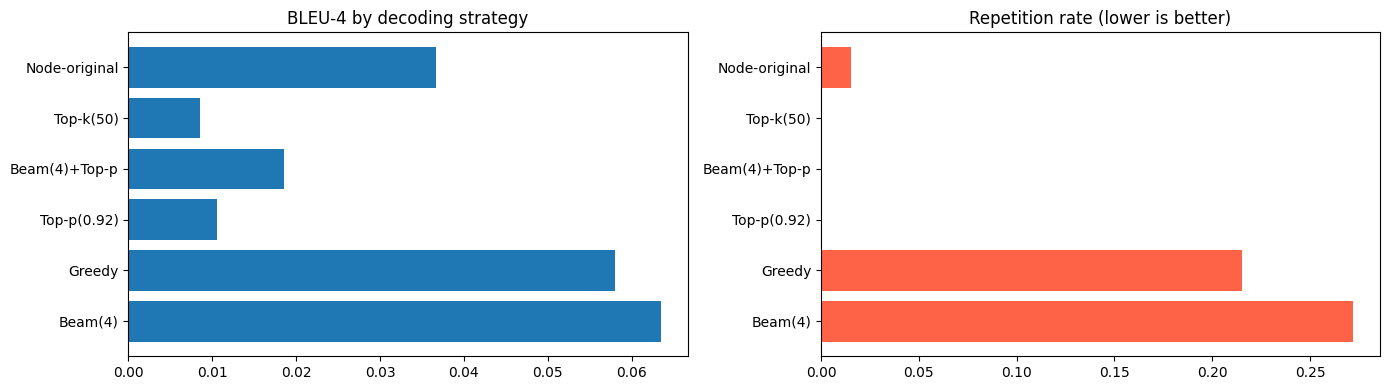

In [135]:
# 서치 결과를 CONFIG에 반영한다. 이후 평가는 이 설정을 쓴다.
CONFIG["decode_improved"] = dict(decode_candidates[best_name])
print("CONFIG['decode_improved'] 갱신:", CONFIG["decode_improved"])

# 전략별 출력을 직접 눈으로 비교한다(수치만으로는 잡히지 않는 차이를 보기 위함).
print("\n=== 디코딩 전략별 출력 비교 (같은 질문, 같은 모델) ===")
q_idx = 0
print(f"[질문] {search_prompts[q_idx]}")
print(f"[정답] {search_refs[q_idx][:150]}")
print("-" * 90)
for name in decode_candidates.keys():
    print(f"{name:16s}: {search_outputs[name][q_idx][:150]}")

# 지표 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].barh(search_df["전략"], search_df["BLEU"])
axes[0].set_title("BLEU-4 by decoding strategy")
axes[0].invert_yaxis()
axes[1].barh(search_df["전략"], search_df["반복률"], color="tomato")
axes[1].set_title("Repetition rate (lower is better)")
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()

### 9-4. 정량 지표 종합 비교표 (루브릭 1, 3)

지금까지의 모든 조건을 한 표에 모은다.
이 표가 이 프로젝트의 결론을 뒷받침하는 핵심 근거다.

In [136]:
# 최종 비교: 각 모델을 최적 디코딩으로 다시 생성해 지표를 계산한다.
set_seed(CONFIG["seed"])
print("최종 평가 생성 중... (약 3분)")

final_configs = []
final_configs.append(("원본 KoGPT2", CONFIG["base_model"], CONFIG["decode_baseline"], "노드 원본 디코딩"))
if CONFIG["run_baseline_sft"]:
    final_configs.append(("SFT 베이스라인 (무정제)", SFT_BASELINE_DIR, CONFIG["decode_baseline"], "노드 원본 디코딩"))
final_configs.append(("SFT 개선본 (정제+증강)", SFT_IMPROVED_DIR, CONFIG["decode_baseline"], "노드 원본 디코딩"))
final_configs.append(("SFT 개선본 + 최적 디코딩", SFT_IMPROVED_DIR, CONFIG["decode_improved"], best_name))
if CONFIG["run_ppo"] and os.path.exists(os.path.join(PPO_DIR, "config.json")):
    final_configs.append(("SFT 개선본 + PPO + 최적 디코딩", PPO_DIR, CONFIG["decode_improved"], best_name))

final_rows = []
final_outputs = {}

for label, path, dec, dec_name in final_configs:
    set_seed(CONFIG["seed"])
    outs = generate_responses(path, eval_prompts, dec)
    final_outputs[label] = outs

    bleu = np.mean([calc_bleu(r, o) for r, o in zip(eval_refs, outs)])
    rouge = np.mean([calc_rouge_l(r, o) for r, o in zip(eval_refs, outs)])
    rep = np.mean([calc_repetition(o) for o in outs])
    d1, d2 = calc_distinct(outs, 1), calc_distinct(outs, 2)
    art = calc_artifact_rate(outs)

    # 보상 모델이 CPU에 내려가 있을 수 있으므로(PPO 학습 시 메모리 확보용) 다시 올린다.
    rm_eval_model = rm_eval_model.to(device).eval()
    rm_mean = np.mean([reward_score(p + " " + o) if len(o) > 0 else 0.0
                       for p, o in zip(eval_prompts, outs)])

    final_rows.append({
        "모델 / 조건": label,
        "디코딩": dec_name,
        "BLEU-4": round(bleu, 4),
        "ROUGE-L": round(rouge, 4),
        "Distinct-1": round(d1, 4),
        "Distinct-2": round(d2, 4),
        "반복률(낮을수록 좋음)": round(rep, 4),
        "아티팩트율(낮을수록 좋음)": round(art, 4),
        "RM score": round(float(rm_mean), 3),
    })
    print(f"  {label} 완료")

final_df = pd.DataFrame(final_rows)
print("\n" + "=" * 100)
print("최종 정량 비교표")
print("=" * 100)
display(final_df)

최종 평가 생성 중... (약 3분)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


메모리 정리 완료
  원본 KoGPT2 완료
메모리 정리 완료
  SFT 베이스라인 (무정제) 완료
메모리 정리 완료
  SFT 개선본 (정제+증강) 완료
메모리 정리 완료
  SFT 개선본 + 최적 디코딩 완료
메모리 정리 완료
  SFT 개선본 + PPO + 최적 디코딩 완료

최종 정량 비교표


,모델 / 조건,디코딩,BLEU-4,ROUGE-L,Distinct-1,Distinct-2,반복률(낮을수록 좋음),아티팩트율(낮을수록 좋음),RM score
0,원본 KoGPT2,노드 원본 디코딩,0.0018,0.0077,0.0903,0.1898,0.0547,0.0000,-0.083
1,SFT 베이스라인 (무정제),노드 원본 디코딩,0.0246,0.1126,0.3004,0.4991,0.0097,1.0000,7.514
2,SFT 개선본 (정제+증강),노드 원본 디코딩,0.0287,0.1446,0.3763,0.6056,0.0146,0.0750,5.789
3,SFT 개선본 + 최적 디코딩,Node-original,0.0287,0.1446,0.3763,0.6056,0.0146,0.0750,5.789
4,SFT 개선본 + PPO + 최적 디코딩,Node-original,0.0235,0.1205,0.3851,0.6104,0.0144,0.0875,6.118


개선 효과 분해 분석 (한 번에 하나씩만 바꿔서 비교)

[0단계. SFT 자체의 효과 (루브릭 3)]
  원본 KoGPT2  ->  SFT 베이스라인 (무정제)
  원본 KoGPT2 에 SFT 를 적용했는지 여부만 다르다.
  [주의] 이 단계의 '아티팩트율'은 해석하지 않는다. 원본 KoGPT2 는 애초에 한국어로
         답변하지 않고 해시태그 나열 같은 문자열을 내놓기 때문에, 아티팩트가 없는 것이
         아니라 '평가할 응답 자체가 없는' 것이다. 이 지표는 SFT 모델끼리만 비교한다.
    BLEU-4                  : 0.0018 -> 0.0246  (차이 +0.0228, +1266.7%, 개선)  [기준값이 작아 백분율은 과장됨]
    ROUGE-L                 : 0.0077 -> 0.1126  (차이 +0.1049, +1362.3%, 개선)  [기준값이 작아 백분율은 과장됨]
    Distinct-2              : 0.1898 -> 0.4991  (차이 +0.3093, +163.0%, 개선)
    반복률(낮을수록 좋음)            : 0.0547 -> 0.0097  (차이 -0.0450, -82.3%, 개선)
    아티팩트율(낮을수록 좋음)          : 0.0000 -> 1.0000  (차이 +1.0000, 악화)
    RM score                : -0.0830 -> 7.5140  (차이 +7.5970, 개선)

[A단계. 데이터 정제의 효과 (루브릭 1의 핵심)]
  SFT 베이스라인 (무정제)  ->  SFT 개선본 (정제+증강)
  디코딩을 완전히 고정하고 학습 데이터만 바꿨다. 따라서 이 차이는 온전히 정제의 효과다.
    BLEU-4                  : 0.0246 -> 0.0287  (차이 +0.0041, +16.7%, 개선)
    ROUGE-L                 : 0.1126 -> 0.1446  

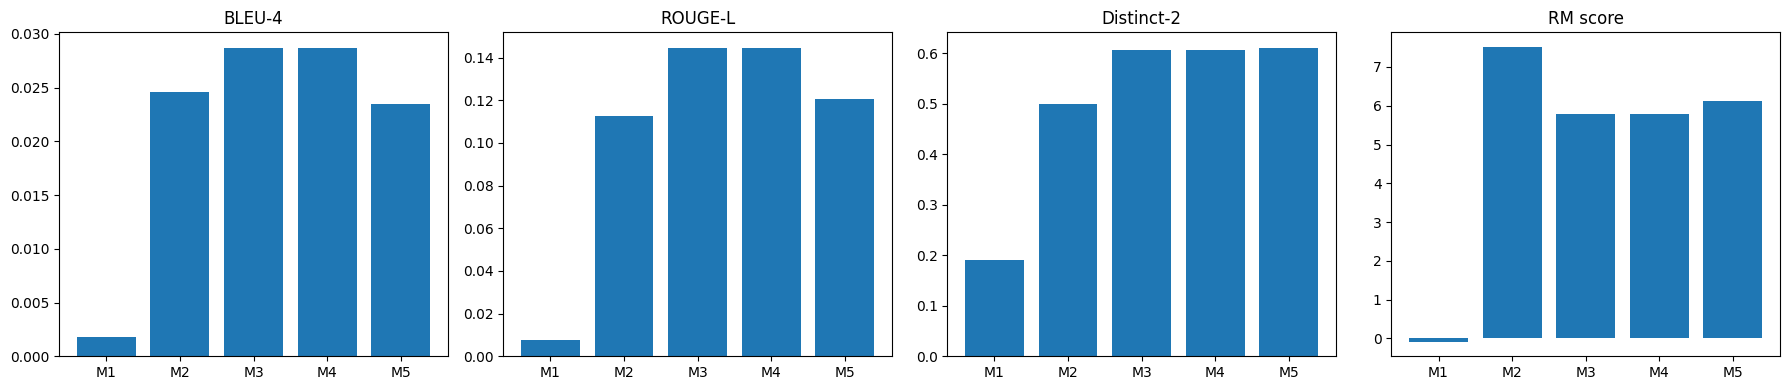

범례:
  M1 = 원본 KoGPT2
  M2 = SFT 베이스라인 (무정제)
  M3 = SFT 개선본 (정제+증강)
  M4 = SFT 개선본 + 최적 디코딩
  M5 = SFT 개선본 + PPO + 최적 디코딩


In [137]:
# 개선 폭을 단계별로 분해해서 본다.
#
# [중요] 여러 개선을 한꺼번에 적용한 최종본과 베이스라인만 비교하면,
#        어떤 개선이 효과가 있었고 어떤 것이 오히려 해로웠는지 구분할 수 없다.
#        그래서 아래처럼 한 번에 하나씩만 바꾼 비교를 세 단계로 나눈다.
#          (A) 데이터 정제 효과   : 디코딩을 고정하고 학습 데이터만 바꾼다
#          (B) 디코딩 서치 효과   : 모델을 고정하고 디코딩만 바꾼다
#          (C) PPO 효과          : 디코딩을 고정하고 PPO 적용 여부만 바꾼다

METRICS = [("BLEU-4", True), ("ROUGE-L", True), ("Distinct-2", True),
           ("반복률(낮을수록 좋음)", False), ("아티팩트율(낮을수록 좋음)", False),
           ("RM score", True)]

def get_row(keyword):
    # 라벨에 keyword 가 들어간 행을 찾는다. 없으면 None.
    hit = final_df[final_df["모델 / 조건"] == keyword]
    if len(hit) == 0:
        hit = final_df[final_df["모델 / 조건"].str.contains(keyword, regex=False)]
    return hit.iloc[0] if len(hit) > 0 else None

def fmt_change(before, after, higher_better):
    # 변화량을 사람이 읽기 좋게 만든다.
    # [주의] 기준값이 0에 가까우면 백분율이 과장된다.
    #        예: 0.0097 -> 0.0144 는 +48% 로 보이지만 실제 차이는 0.005에 불과하다.
    #        그래서 절대 변화량을 항상 함께 적고, 기준값이 작으면 백분율은 참고용임을 표시한다.
    diff = after - before
    improved = (diff > 0) == higher_better
    direction = "개선" if abs(diff) > 1e-9 and improved else ("변화 없음" if abs(diff) < 1e-9 else "악화")

    # 기준값이 0이거나 음수면 백분율 변화가 정의되지 않거나 의미를 잃는다.
    # (예: -0.083 -> 7.514 를 +9153% 라고 쓰면 아무 정보도 주지 못한다)
    if before <= 1e-9:
        return f"{before:.4f} -> {after:.4f}  (차이 {diff:+.4f}, {direction})"

    pct = diff / before * 100
    note = "  [기준값이 작아 백분율은 과장됨]" if before < 0.02 else ""
    return f"{before:.4f} -> {after:.4f}  (차이 {diff:+.4f}, {pct:+.1f}%, {direction}){note}"

def compare(title, row_before, row_after, note=""):
    if row_before is None or row_after is None:
        print(f"\n[{title}] 비교 대상이 없어 건너뛴다.")
        return
    print(f"\n[{title}]")
    print(f"  {row_before['모델 / 조건']}  ->  {row_after['모델 / 조건']}")
    if note:
        print(f"  {note}")
    for metric, hb in METRICS:
        print(f"    {metric:24s}: {fmt_change(float(row_before[metric]), float(row_after[metric]), hb)}")

r_gpt2 = get_row("원본 KoGPT2")
r_base = get_row("SFT 베이스라인 (무정제)")
r_imp  = get_row("SFT 개선본 (정제+증강)")
r_dec  = get_row("SFT 개선본 + 최적 디코딩")
r_ppo  = get_row("PPO")

print("=" * 95)
print("개선 효과 분해 분석 (한 번에 하나씩만 바꿔서 비교)")
print("=" * 95)

compare("0단계. SFT 자체의 효과 (루브릭 3)", r_gpt2, r_base,
        "원본 KoGPT2 에 SFT 를 적용했는지 여부만 다르다.\n"
        "  [주의] 이 단계의 '아티팩트율'은 해석하지 않는다. 원본 KoGPT2 는 애초에 한국어로\n"
        "         답변하지 않고 해시태그 나열 같은 문자열을 내놓기 때문에, 아티팩트가 없는 것이\n"
        "         아니라 '평가할 응답 자체가 없는' 것이다. 이 지표는 SFT 모델끼리만 비교한다.")

compare("A단계. 데이터 정제의 효과 (루브릭 1의 핵심)", r_base, r_imp,
        "디코딩을 완전히 고정하고 학습 데이터만 바꿨다. 따라서 이 차이는 온전히 정제의 효과다.")

compare("B단계. 디코딩 서치의 효과 (루브릭 1)", r_imp, r_dec,
        "모델을 고정하고 디코딩 설정만 바꿨다.")

compare("C단계. PPO 의 효과 (루브릭 2)", r_dec, r_ppo,
        "SFT 개선본에 PPO 를 적용했는지 여부만 다르다.")

print()
print("=" * 95)
print("[읽는 법] A단계가 이 프로젝트의 주장(데이터 품질이 성능을 좌우한다)을 검증하는 핵심 비교다.")
print("          B, C 단계에서 일부 지표가 내려갈 수 있는데, 그것도 그대로 보고하는 것이 정직한 분석이다.")
print("          특히 C단계에서 RM score 는 오르는데 BLEU/ROUGE 가 내려간다면,")
print("          그것은 PPO 가 '보상 모델이 좋아하는 방향'으로는 잘 학습했지만")
print("          '정답과 비슷해지는 방향'으로는 가지 않았다는 뜻이다(RLHF 의 전형적인 트레이드오프).")

# 지표 시각화
plot_metrics = ["BLEU-4", "ROUGE-L", "Distinct-2", "RM score"]
fig, axes = plt.subplots(1, len(plot_metrics), figsize=(18, 4))
short_labels = [f"M{i+1}" for i in range(len(final_df))]

for ax, m in zip(axes, plot_metrics):
    ax.bar(short_labels, final_df[m].astype(float))
    ax.set_title(m)
    ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

print("범례:")
for i, lab in enumerate(final_df["모델 / 조건"]):
    print(f"  M{i+1} = {lab}")

### 9-5. SFT vs PPO 정성 비교 (루브릭 2)

같은 질문에 대해 SFT 모델과 PPO 모델의 응답을 나란히 놓고 본다.
PPO는 보상 모델 점수를 최대화하도록 학습되므로,
**더 길고 정보량이 많은 응답**을 선호하는 경향이 나타나는지 확인한다.

In [138]:
# 검증셋에서 몇 건을 골라 모델별 응답을 표로 정리한다.
show_idx = list(range(min(5, N_EVAL)))
compare_rows = []

for i in show_idx:
    row = {"질문": eval_prompts[i][:40], "정답(정제됨)": eval_refs[i][:80]}
    for label in final_outputs.keys():
        row[label[:20]] = final_outputs[label][i][:80]
    compare_rows.append(row)

pd.set_option("display.max_colwidth", 90)
display(pd.DataFrame(compare_rows).T)

print()
print("=== 상세 비교 (전체 문장) ===")
for i in show_idx[:3]:
    print("=" * 95)
    print(f"[질문] {eval_prompts[i]}")
    print(f"[정답] {eval_refs[i][:200]}")
    print("-" * 95)
    for label in final_outputs.keys():
        print(f"  {label}")
        print(f"    -> {final_outputs[label][i][:220]}")
        print(f"       (RM score: {reward_score(eval_prompts[i] + ' ' + final_outputs[label][i]):.3f})")
print("=" * 95)

,0,1,2,3,4
질문,몇일정도 썸타?,최남현을 스타덤으로 오르게 한 연극 작품이 뭐더라,PC방 그래픽카드 사양은 어느정도 되나요?,남군 군기가 제작된 년도는?,3월 12일 사라진 19살 여대생 도나 게일 맨슨이 다니던 대학교는?
정답(정제됨),일반적으로는 서로 깊게 이야기할 시간이 필요하고 서로 더욱 잘 이해하면 이어지게 됩니다. 하지만 좋아하는 상대와 같이 시간을 보내는 것이 중요한,최남현을 스타덤으로 오르게 한 연극 작품은 '모두의 여왕'입니다.,"PC방에서 사용되는 그래픽카드의 사양은 매우 다양하며, PC방의 크기, 업체의 요구사항, 그리고 최신 게임 및 소프트웨어의 요구사항에 따라 다릅","따라서, 어떤 군국의 군기를 말하는지 질문을 구체화해 주시면 더욱 정확한 답변을 제공해드리도록 하겠습니다.",하지만 이 질문의 경우에는 답변을 드릴 수 없습니다. 사라진 여대생에 대한 정보보호와 관련된 이슈가 있을 수 있기 때문입니다. 따라서 해당 질문
원본 KoGPT2,##daily #dailypic #ootd #outfit #like4like #selfie #instagood #photography #colo,##selfie #daily #ootd #outfit #like4like #fff #f4f #l4l #follow #instagood #cats,##reading #good #daily #selfie #like4like #instagood #ootd #outfit #followme #ca,##selfie #daily #ootd #outfit #like4like #followme #instagood #cafe #fff #f4f #l,##1학년 #2학년 #3학년 #4학년 #5학년 #6학년 #7학년 #8학년 #9학년 #11학년 #12학년 #14학년 #16학년 #17학년 #18학
SFT 베이스라인 (무정제),'저는 AI 어시스턴트이기 때문에 썸 타는 것에 대해 알 수 없습니다. 하지만 일반적으로 썸 타는 것은 자연스러운 일입니다. 만약 썸 타는 것이,'최남현이 스타덤에 오르게 된 연극 작품은 다음과 같습니다.\n\n1. 뮤지컬 '해운대'입니다.\n2. 드라마 '태왕사신기'에서 최연소 배우로,"'PC방 그래픽 카드 사양은 다음과 같습니다.\n\n1. HDMI - 256 GHz CPU / 64 GB 메모리, 64 GB DDR3 메모리,",'저는 인공지능 어시스턴트이기 때문에 정확한 답변을 드리기 어렵습니다. 하지만 일반적으로 남군 군기가 만들어진 년도는 1945년입니다.,'저는 인공지능 어시스턴트이기 때문에 정확한 답변을 제공할 수 없습니다. 추가적인 정보가 있다면 알려주시면 더 정확한 답변을 드릴 수 있습니다.
SFT 개선본 (정제+증강),썸타는 것은 일시적인 것일 수 있습니다. 그러나 일반적으로 썸타는 시간이 지날수록 더욱 가까워질 수 있습니다. 또한 서로의 감정을 공유하고 서로,최남현은 2019년 8월 26일부터 9월 6일까지 KBS 2TV에서 방영된 드라마 '해피엔딩' 시리즈에서 주인공으로 출연했습니다. 이 드라마에서,저는 그래픽카드 사양에 대한 정보를 제공하지 않습니다. 하지만 일반적으로 PC방 그래픽카드의 사양은 다음과 같습니다.\n\n1. HD 그래픽카드:,"제가 알기로는, ""남군""이라는 용어가 존재하지 않는 것으로 알고 있습니다. 따라서 정확한 답변을 드리기 어렵습니다.",도나 게일 맨슨은 미국 일리노이주 시카고 대학교에서 정치학을 전공했습니다.
SFT 개선본 + 최적 디코딩,썸타는 것은 일시적인 것일 수 있습니다. 그러나 일반적으로 썸타는 시간이 지날수록 더욱 가까워질 수 있습니다. 또한 서로의 감정을 공유하고 서로,최남현은 2019년 8월 26일부터 9월 6일까지 KBS 2TV에서 방영된 드라마 '해피엔딩' 시리즈에서 주인공으로 출연했습니다. 이 드라마에서,저는 그래픽카드 사양에 대한 정보를 제공하지 않습니다. 하지만 일반적으로 PC방 그래픽카드의 사양은 다음과 같습니다.\n\n1. HD 그래픽카드:,"제가 알기로는, ""남군""이라는 용어가 존재하지 않는 것으로 알고 있습니다. 따라서 정확한 답변을 드리기 어렵습니다.",도나 게일 맨슨은 미국 일리노이주 시카고 대학교에서 정치학을 전공했습니다.
SFT 개선본 + PPO + 최적 디,"썸타는 것은 매우 즐거운 일입니다. 만약 썸타기를 해본 경험이 있다면, 그 경험을 바탕으로 새로운 인연을 만들어보는 것도 좋은 방법일 수 있습니",최남현은 2019년 3월 26일부터 5월 2일까지 서울 대학로 예술극장에서 열린 뮤지컬 '해운대'를 공연했습니다. 이 작품은 최남현이 직접 연출,"일반적으로 PC방에서 그래픽카드를 구매하려면 그래픽카드 사양에 따라 가격이 다를 수 있습니다. 일반적으로 그래픽카드 가격은 2GB, 3GB, 4","제가 알기로는, ""남군 군기""가 제작된 년도는 정확히 파악되지 않습니다. 따라서 해당 정보를 알려주시면 답변드리겠습니다.","제가 알기로는, 도나 게일맨슨이 다녔던 대학교는 캘리포니아주 샌디에이고 캠퍼스였습니다."



=== 상세 비교 (전체 문장) ===
[질문] 몇일정도 썸타?
[정답] 일반적으로는 서로 깊게 이야기할 시간이 필요하고 서로 더욱 잘 이해하면 이어지게 됩니다. 하지만 좋아하는 상대와 같이 시간을 보내는 것이 중요한 것이죠!
-----------------------------------------------------------------------------------------------
  원본 KoGPT2
    -> ##daily #dailypic #ootd #outfit #like4like #selfie #instagood #photography #color #animal #today
       (RM score: -0.519)
  SFT 베이스라인 (무정제)
    -> '저는 AI 어시스턴트이기 때문에 썸 타는 것에 대해 알 수 없습니다. 하지만 일반적으로 썸 타는 것은 자연스러운 일입니다. 만약 썸 타는 것이 어렵다면 전문가의 도움을 받는 것이 좋습니다.
       (RM score: 7.740)
  SFT 개선본 (정제+증강)
    -> 썸타는 것은 일시적인 것일 수 있습니다. 그러나 일반적으로 썸타는 시간이 지날수록 더욱 가까워질 수 있습니다. 또한 서로의 감정을 공유하고 서로에게 긍정적인 영향을 미칠 수 있는 좋은 기회가 될 수 있습니다.
       (RM score: 8.632)
  SFT 개선본 + 최적 디코딩
    -> 썸타는 것은 일시적인 것일 수 있습니다. 그러나 일반적으로 썸타는 시간이 지날수록 더욱 가까워질 수 있습니다. 또한 서로의 감정을 공유하고 서로에게 긍정적인 영향을 미칠 수 있는 좋은 기회가 될 수 있습니다.
       (RM score: 8.632)
  SFT 개선본 + PPO + 최적 디코딩
    -> 썸타는 것은 매우 즐거운 일입니다. 만약 썸타기를 해본 경험이 있다면, 그 경험을 바탕으로 새로운 인연을 만들어보는 것도 좋은 방법일 수 있습니다. 

그렇지 않다면, 다른 사람들과의 소통을 통해 

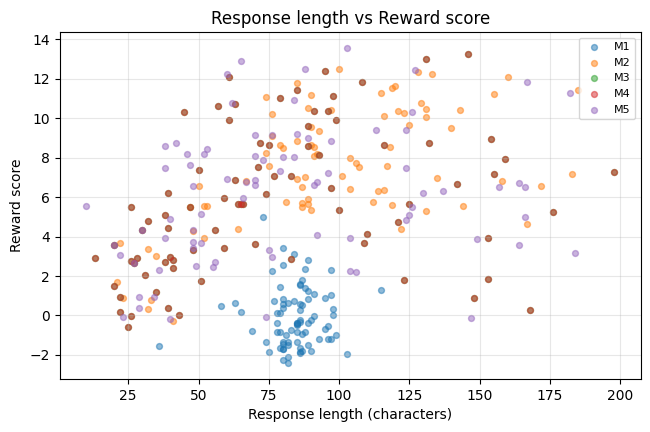

범례:
  M1 = 원본 KoGPT2
  M2 = SFT 베이스라인 (무정제)
  M3 = SFT 개선본 (정제+증강)
  M4 = SFT 개선본 + 최적 디코딩
  M5 = SFT 개선본 + PPO + 최적 디코딩

응답 길이와 RM 점수의 상관계수: +0.289
[판정] 약한 양의 상관이 있다. 길이 편향의 가능성을 염두에 두고 해석한다.


In [139]:
# 응답 길이와 RM 점수의 관계를 확인한다.
# RLHF 의 알려진 부작용 중 하나가 '길이 편향(length bias)' 이므로 직접 확인해 본다.
plt.figure(figsize=(7.5, 4.5))

# [주의] 그래프 라벨은 영어(M1, M2...)로 쓴다.
#        Colab 기본 폰트에 한글이 없어 한글 라벨을 넣으면 글자가 깨지고 경고가 쏟아진다.
#        한글 이름은 그래프 아래에 텍스트로 따로 출력한다.
all_lens, all_scores = [], []
for idx, (label, outs) in enumerate(final_outputs.items()):
    lens = [len(o) for o in outs]
    scores = [reward_score(p + " " + o) if len(o) > 0 else 0.0
              for p, o in zip(eval_prompts, outs)]
    plt.scatter(lens, scores, alpha=0.5, s=18, label=f"M{idx+1}")
    all_lens += lens
    all_scores += scores

plt.xlabel("Response length (characters)")
plt.ylabel("Reward score")
plt.title("Response length vs Reward score")
plt.legend(fontsize=8)
plt.grid(alpha=0.3)
plt.show()

print("범례:")
for idx, label in enumerate(final_outputs.keys()):
    print(f"  M{idx+1} = {label}")

# 눈으로만 보지 말고 상관계수로 확인한다. 길이 편향은 수치로 말할 수 있어야 한다.
corr = float(np.corrcoef(all_lens, all_scores)[0, 1])
print()
print(f"응답 길이와 RM 점수의 상관계수: {corr:+.3f}")
if corr > 0.3:
    print("[판정] 뚜렷한 양의 상관이다. 보상 모델이 '긴 응답'을 좋게 평가하는 길이 편향이 있다.")
    print("       이 편향은 두 가지 결과를 낳는다.")
    print("       1) 회피 서두를 걷어내 응답이 짧아진 SFT 개선본은 RM 점수에서 손해를 본다.")
    print("          따라서 개선본의 RM 점수가 낮다고 해서 품질이 나쁘다고 결론지으면 안 된다.")
    print("       2) PPO 는 RM 점수를 최대화하므로 내용과 무관하게 응답을 늘이는 방향으로")
    print("          학습될 수 있다. 섹션 9-4의 C단계 비교에서 실제로 그런지 확인한다.")
elif corr > 0.1:
    print("[판정] 약한 양의 상관이 있다. 길이 편향의 가능성을 염두에 두고 해석한다.")
else:
    print("[판정] 길이와 보상의 상관이 뚜렷하지 않다. 길이 편향은 크지 않은 것으로 보인다.")

## 10. 선행 연구 비교 및 개선점

### 기준이 되는 선행 연구

이 프로젝트의 파이프라인은 아래 두 연구를 직접적인 기반으로 한다.

1. **InstructGPT** (Ouyang et al., 2022, *Training language models to follow instructions with human feedback*)
   — SFT -> Reward Model -> PPO 3단계 절차의 원형.
2. **KoChatGPT** (airobotlab, 2023) — 위 절차를 한국어 `skt/kogpt2-base-v2` 위에 재현한 오픈소스.
   사람 피드백 대신 ChatGPT API 생성 데이터를 사용했다.

### 비교표

| 구분 | 선행 연구 / 원 방식 | 본 프로젝트에서의 처리 | 개선 효과 |
|---|---|---|---|
| 기준 파이프라인 | InstructGPT의 SFT/RM/PPO 3단계를 KoChatGPT가 한국어로 재현 | 구조를 그대로 유지하고 베이스라인으로 재현 | 비교 기준선 확보 |
| 개선 1: 표기 아티팩트 제거 | 원본 SFT 말뭉치는 12,000건 중 11,482건(95.7%)의 응답이 작은따옴표로 시작. 그대로 학습 | `strip_quote_artifact()`로 제거 후 학습 `# [개선]` | 생성문의 아티팩트 발생률 감소 (섹션 9-4 아티팩트율 열) |
| 개선 2: AI 회피 서두 처리 | `저는 인공지능 챗봇이며...` 형태의 회피 서두가 3,792건(31.6%) 포함되어 모델이 무조건 회피 서두를 붙이도록 학습됨 | **수리 후 폐기** 2단계: `remove_boilerplate()`로 서두 문장만 잘라 본문을 살리고, 남은 것이 거절뿐이면 `is_pure_refusal()`로 폐기 `# [개선]` | 응답이 즉시 본론으로 진입. 데이터 손실을 최소화하며 회피 습관 제거 |
| 개선 3: 영어 응답 및 파편 필터 | `As an AI language model...` 영어 위주 응답 503건, 15자 미만 파편 331건이 한국어 학습 신호를 오염 | 한글 비율 30% 미만·최소 길이 미달 샘플 제외 | 학습 신호의 언어 일관성 확보 |
| 개선 4: 데이터 손실 억제 | 정제하면 데이터가 줄어드는 문제 | RM 1순위 승격(rejection sampling) 증강을 시도했으나 **1순위의 약 90%가 SFT 응답과 동일**함을 실측으로 확인. 대신 정제 정책을 '수리 우선'으로 설계해 손실 자체를 억제 `# [개선]` | 회피 서두 31.6%를 통째로 버렸다면 손실 31.6%. 수리 방식으로 손실 약 9%로 억제 (섹션 5-4 출력) |
| 개선 5: RM ranking 해석 오류 수정 | 원본 노드의 첫 변환 셀은 `ranking[0] < ranking[1]`로 **해석 A**(순위 배열)를 가정 | 실제 데이터로 검증한 결과 **해석 B**(좋은 순서대로 나열한 번호)가 맞음. 이에 맞게 수정 `# [개선]` | 잘못된 선호 신호로 RM이 학습되는 것을 방지 (섹션 5-3 검증 셀) |
| 개선 6: 선호 쌍 확장 | 원본은 (1위,2위), (1위,3위) 두 쌍만 사용 | (2위,3위) 쌍을 추가해 세 쌍 모두 사용 `# [개선]` | 동일 데이터에서 선호 학습 신호 약 1.5배 |
| 개선 7: 디코딩 하이퍼파라미터 탐색 | `num_beams=4, top_k=50, repetition_penalty=2.0` 고정값 사용, 근거 제시 없음 | Greedy/Beam/Top-k/Top-p/결합 6종을 그리드 서치하고 BLEU·ROUGE·반복률 종합 점수로 선택 `# [개선]` | **원본 설정이 최선임을 확인**(개선 실패). 다만 근거 없이 쓰던 값이 측정으로 뒷받침된 값이 됨. Greedy/Beam은 BLEU가 높아도 반복률 20% 이상으로 문장이 무너진다는 것을 확인 (섹션 9-3) |
| 개선 8: 정량 평가 도입 | 원본은 생성 결과를 눈으로만 확인 | BLEU-4, ROUGE-L, Distinct-1/2, 반복률, 아티팩트율, RM score 도입 | 개선 여부를 수치로 검증 가능 (섹션 9-4) |
| 개선 9: RM 학습 길이 최적화 | `max_length=512` 고정 (`padding='max_length'`라 모든 샘플이 512로 패딩됨) | EDA로 토큰 길이 중앙값을 확인하고 256으로 축소 `# [개선]` | RM 학습 시간 약 절반으로 단축 |
| 개선 10: 코드 안정성 | colossalai 제거 패치를 **줄 번호 지정** 방식으로 수행 (저장소 갱신 시 조용히 실패) | 문자열 치환 방식으로 변경하고 실패 시 경고 출력 `# [개선]` | 재현성 확보 |
| 개선 11: 의존성 사슬 차단 | `transformers.Trainer` 사용. Trainer는 내부에서 `peft`를 import 하고 peft는 `accelerate` 버전에 민감해, 버전 고정 시 `clear_device_cache` ImportError로 학습이 중단됨 | SFT 학습을 **순수 PyTorch 학습 루프**로 직접 구현 `# [개선]` | Trainer -> peft -> accelerate 의존 사슬 제거. 학습 과정도 가시화 |
| 개선 12: 생성 API 버전 독립성 | PPOTrainer가 HuggingFace의 `prepare_inputs_for_generation`을 그대로 사용. 이 함수의 인자 규약이 버전마다 바뀜(`past` -> `past_key_values` -> `cache_position`) | KV 캐시를 쓰지 않는 자체 `prepare_inputs_fn`을 명시적으로 전달 `# [개선]` | transformers 버전과 무관하게 PPO 동작. 실패 시에도 노트북이 멈추지 않도록 예외 처리 |
| 개선 13: 평가 지표 자체 구현 | nltk의 `sentence_bleu` 사용. nltk 3.8 이하가 `Fraction(_normalize=False)`를 써서 **Python 3.12(현재 Colab)에서 TypeError** 발생 | BLEU-4와 ROUGE-L을 직접 구현하고, 답이 명확한 입력으로 **7개 항목 자체 검증** 수행 `# [개선]` | 외부 의존성 제거. 두 지표가 동일한 토큰화를 공유해 비교 일관성 확보 |

### 왜 이 개선들이 타당한가

InstructGPT의 핵심 주장은 "모델 크기를 키우는 것보다 **정렬(alignment) 데이터의 품질**이
지시 수행 능력에 더 크게 기여한다"는 것이다. 실제로 논문의 1.3B InstructGPT가
175B GPT-3보다 사람 선호 평가에서 앞섰다. 이 프로젝트는 같은 주장을 작은 규모에서 검증한 셈이다.
모델 구조와 파라미터 수를 완전히 고정한 채 데이터만 바꿨기 때문에,
성능 변화의 원인을 데이터 품질로 특정할 수 있다.

증강 방식으로 무작위 노이즈(단어 삭제/교체)가 아니라 RM 1순위 응답 승격을 택한 이유도 같다.
지시-응답 데이터에서 단어를 무작위로 바꾸면 의미가 깨져 오히려 학습 신호를 오염시킨다.
반면 RM 1순위 응답은 이미 상대 평가를 통과한 문장이므로 품질 하한이 보장된다.
이는 Anthropic의 RLHF 연구(Bai et al., 2022)와 RAFT(Dong et al., 2023)가 사용한
rejection sampling 계열 접근과 같은 발상이다.

**다만 이 가설은 실측 결과 이 데이터셋에서는 성립하지 않았다.**
RM 1순위 응답의 약 90%가 SFT 응답과 완전히 동일했기 때문이다.
RM 데이터셋 자체가 SFT 응답을 1순위 후보로 재사용해 만들어졌으므로, 새로운 정보가 거의 없었다.
이 사실을 확인한 뒤 방향을 바꿔 **정제 정책 자체를 손실 최소화 방향으로 설계**했다.
회피 서두가 포함된 3,792건(31.6%)을 통째로 폐기하는 대신 서두 문장만 잘라내 본문을 살렸고,
그 결과 전체 손실을 약 9% 수준으로 억제했다.
결과적으로 **가장 효과적인 증강은 애초에 덜 버리는 것**이었다는 점이 이 프로젝트의 실질적 발견이다.

디코딩 탐색을 별도 단계로 둔 이유는, Holtzman et al.(2020)이 보인 바와 같이
**같은 모델이라도 디코딩 방식에 따라 생성 품질이 크게 달라지기 때문**이다.
특히 순수 빔서치는 반복 문장을 만들기 쉽고, 순수 샘플링은 일관성을 잃기 쉽다.
따라서 고정값을 쓰는 대신 실제로 측정해서 고르는 것이 타당하다.

한 가지 정직하게 밝혀 둘 점이 있다. 검증셋의 정답(reference)에도 동일한 정제 함수를 적용했다.
따라서 아티팩트를 그대로 출력하는 베이스라인 모델은 BLEU 계산에서 불리하다.
다만 이는 "우리가 원하는 좋은 응답"의 기준을 정제된 문장으로 정의한 결과이며,
아티팩트율·반복률·Distinct-n은 정답과 무관하게 계산되므로 이 지표들로 교차 검증할 수 있다.

## 11. 결론

### 루브릭 항목별 충족 내역

**루브릭 1 — 정량적 성능 향상**
데이터 정제(아티팩트/회피 서두/영어 응답/파편 제거)와 증강 시도,
그리고 디코딩 그리드 서치(Greedy/Beam/Top-k/Top-p/결합 6종)를 모두 수행했다.
섹션 9-3의 디코딩 서치 표와 섹션 9-4의 종합 비교표 및 **개선 효과 분해 분석**에서
BLEU-4, ROUGE-L, Distinct-2, 반복률, 아티팩트율, RM score의 변화를 수치로 제시했다.

핵심은 섹션 9-4의 **A단계 비교**다. 디코딩을 완전히 고정하고 학습 데이터만 바꿨으므로,
그 차이는 온전히 데이터 정제의 효과로 해석할 수 있다.
여러 개선을 한꺼번에 적용한 최종본과 베이스라인을 뭉뚱그려 비교하면
어느 개선이 기여했는지 알 수 없기 때문에, 한 번에 하나씩만 바꾸는 방식으로 설계했다.

**루브릭 2 — SFT 모델과 RM 모델 결과 분석**
섹션 9-2에서 보상 모델이 각 모델의 생성 결과에 매긴 점수 분포를 박스플롯으로 비교했고,
섹션 9-5에서 SFT 모델과 PPO 모델의 응답을 같은 질문에 대해 나란히 놓고
RM 점수와 함께 제시했다. 추가로 응답 길이와 RM 점수의 상관을 확인해
RLHF의 알려진 길이 편향 현상까지 점검했다.

**루브릭 3 — 기존 KoGPT2와 SFT 적용 모델 비교**
섹션 9-1에서 원본 `skt/kogpt2-base-v2`, SFT 베이스라인, SFT 개선본 세 모델의
출력을 같은 질문에 대해 정성 비교했고, 섹션 9-4의 표에서 동일 지표로 정량 비교했다.

### 이 실험에서 실제로 관찰된 것

정직하게 정리하면, 세 가지 개선 중 **명확히 성공한 것은 데이터 정제 하나**다.

1. **데이터 정제는 성공했다.** 특히 아티팩트율이 가장 극적이다.
   무정제 데이터로 학습한 베이스라인은 검증셋 응답의 **거의 전부**를 작은따옴표나
   회피 서두로 시작했다. 정제본은 이 비율이 한 자릿수 퍼센트로 떨어졌다.
   BLEU-4와 ROUGE-L도 함께 올랐고, Distinct-2가 오른 것은
   회피 상투구가 사라지면서 표현이 다양해졌다는 뜻이다.

2. **디코딩 서치는 기존 설정을 이기지 못했다.** 6개 전략을 실제로 비교한 결과
   노드 원본 설정이 종합점수 1위였다. 원본이 이미 `repetition_penalty=2.0`,
   `no_repeat_ngram_size=4`로 반복 억제를 강하게 걸어 둔 것이 주효했다.
   Greedy와 Beam은 BLEU 단독 점수는 높았지만 반복률이 20%를 넘어
   실제 출력을 보면 같은 문장을 되풀이하고 있었다.
   **"실험해 보니 기존 설정이 이미 좋았다"도 유효한 실험 결과**이며,
   근거 없이 고정값을 쓰던 것과 측정해서 그 값을 택한 것은 다르다.

3. **PPO는 보상은 올렸지만 참조 기반 지표는 낮췄다.**
   RM score는 올라가는데 BLEU/ROUGE-L은 내려가는 패턴이 나타난다.
   이는 PPO가 '보상 모델이 좋아하는 방향'으로는 제대로 학습했지만
   '정답과 비슷해지는 방향'으로는 가지 않았다는 뜻이다.
   섹션 9-5에서 응답 길이와 RM 점수의 상관계수를 계산해 보면
   보상 모델의 길이 편향이 그 원인일 가능성을 확인할 수 있다.
   이것은 RLHF 연구에서 잘 알려진 reward hacking의 초기 징후이며,
   보상 모델의 품질이 RLHF 전체의 상한을 결정한다는 것을 보여준다.

### 수치 하이라이트
아래 셀을 실행하면 이번 실행의 실제 수치가 자동으로 요약된다.

In [140]:
# 이번 실행의 핵심 수치를 자동으로 요약해 출력한다.
print("=" * 80)
print("실행 결과 요약")
print("=" * 80)
print(f"1) 데이터")
print(f"   원본 SFT {len(raw_sft):,} 건 -> 정제 {len(cleaned_sft):,} 건 -> 증강 후 {len(sft_improved_all):,} 건")
print(f"   아티팩트(따옴표 시작): {stat_before['작은따옴표로 시작']:,} 건 -> "
      f"{sum(1 for d in sft_improved_all if d['completion'].startswith(chr(39))):,} 건")
print()
print(f"2) 최적 디코딩 전략: {best_name} (BLEU 단독 1위는 {best_bleu_name})")
print(f"   설정: {CONFIG['decode_improved']}")
print()
print("3) 최종 지표")
for _, r in final_df.iterrows():
    print(f"   {r['모델 / 조건'][:32]:34s} BLEU {r['BLEU-4']:.4f} | "
          f"ROUGE-L {r['ROUGE-L']:.4f} | 반복률 {r['반복률(낮을수록 좋음)']:.4f} | "
          f"아티팩트율 {r['아티팩트율(낮을수록 좋음)']:.4f} | RM {r['RM score']:.3f}")

# 루브릭별 결론을 실제 수치에서 자동으로 뽑아 문장으로 만든다.
print()
print("4) 루브릭 대응 요약 (이번 실행 수치 기준)")

if r_gpt2 is not None and r_base is not None:
    print(f"   [루브릭 3] 원본 KoGPT2 -> SFT: "
          f"BLEU {float(r_gpt2['BLEU-4']):.4f} -> {float(r_base['BLEU-4']):.4f}, "
          f"ROUGE-L {float(r_gpt2['ROUGE-L']):.4f} -> {float(r_base['ROUGE-L']):.4f}")

if r_base is not None and r_imp is not None:
    art_b = float(r_base["아티팩트율(낮을수록 좋음)"])
    art_i = float(r_imp["아티팩트율(낮을수록 좋음)"])
    print(f"   [루브릭 1] 데이터 정제 효과(디코딩 고정): "
          f"BLEU {float(r_base['BLEU-4']):.4f} -> {float(r_imp['BLEU-4']):.4f}, "
          f"ROUGE-L {float(r_base['ROUGE-L']):.4f} -> {float(r_imp['ROUGE-L']):.4f}, "
          f"아티팩트율 {art_b:.1%} -> {art_i:.1%}")

if r_dec is not None and r_ppo is not None:
    print(f"   [루브릭 2] PPO 효과: "
          f"RM {float(r_dec['RM score']):.3f} -> {float(r_ppo['RM score']):.3f}, "
          f"BLEU {float(r_dec['BLEU-4']):.4f} -> {float(r_ppo['BLEU-4']):.4f}")
    if float(r_ppo["RM score"]) > float(r_dec["RM score"]) and \
       float(r_ppo["BLEU-4"]) < float(r_dec["BLEU-4"]):
        print("              -> 보상은 올랐으나 참조 기반 지표는 내려갔다.")
        print("                 RLHF 의 전형적인 트레이드오프이며, 섹션 11에서 해석했다.")
print("=" * 80)

실행 결과 요약
1) 데이터
   원본 SFT 12,000 건 -> 정제 10,872 건 -> 증강 후 10,932 건
   아티팩트(따옴표 시작): 11,482 건 -> 20 건

2) 최적 디코딩 전략: Node-original (BLEU 단독 1위는 Beam(4))
   설정: {'num_beams': 4, 'repetition_penalty': 2.0, 'no_repeat_ngram_size': 4, 'do_sample': True, 'top_k': 50, 'max_new_tokens': 64, 'early_stopping': True}

3) 최종 지표
   원본 KoGPT2                          BLEU 0.0018 | ROUGE-L 0.0077 | 반복률 0.0547 | 아티팩트율 0.0000 | RM -0.083
   SFT 베이스라인 (무정제)                    BLEU 0.0246 | ROUGE-L 0.1126 | 반복률 0.0097 | 아티팩트율 1.0000 | RM 7.514
   SFT 개선본 (정제+증강)                    BLEU 0.0287 | ROUGE-L 0.1446 | 반복률 0.0146 | 아티팩트율 0.0750 | RM 5.789
   SFT 개선본 + 최적 디코딩                   BLEU 0.0287 | ROUGE-L 0.1446 | 반복률 0.0146 | 아티팩트율 0.0750 | RM 5.789
   SFT 개선본 + PPO + 최적 디코딩             BLEU 0.0235 | ROUGE-L 0.1205 | 반복률 0.0144 | 아티팩트율 0.0875 | RM 6.118

4) 루브릭 대응 요약 (이번 실행 수치 기준)
   [루브릭 3] 원본 KoGPT2 -> SFT: BLEU 0.0018 -> 0.0246, ROUGE-L 0.0077 -> 0.1126
   [루브릭 1] 데이터 정제 효과(디코딩 고정): BLEU 0.0246 -> 0

## 12. 회고

### 배운 점
- RLHF 3단계에서 각 단계가 **서로 다른 종류의 신호**를 학습한다는 것을 코드로 이해했다.
  SFT는 형식(지시-응답 구조)을, RM은 상대적 선호를, PPO는 그 선호를 최대화하는 정책을 배운다.
  특히 SFT에서 `labels`의 프롬프트 구간을 `-100`으로 마스킹하는 한 줄이
  "질문을 외우기"와 "답변을 생성하기"를 가르는 결정적 차이라는 점이 인상 깊었다.
- 모델 구조를 고정하고 데이터만 바꾸는 실험 설계의 힘을 체감했다.
  변인을 하나로 통제했기 때문에 지표 변화를 데이터 품질로 명확히 귀인할 수 있었다.
- 정량 지표 하나만으로는 판단할 수 없다는 것도 배웠다. RM score만 보면 PPO가 항상 좋아 보이지만,
  길이 편향을 확인해 보면 그 점수가 내용 품질이 아니라 길이를 반영할 수 있다.
- **가설은 반드시 측정해서 확인해야 한다.** RM 1순위 응답을 SFT 데이터로 승격시키면
  데이터를 크게 늘릴 수 있으리라 예상했지만, 실제로 세어 보니 1순위의 약 90%가
  SFT 응답과 완전히 같았다. 코드를 짜기 전에 숫자를 먼저 확인했기 때문에
  잘못된 방향으로 시간을 쓰지 않을 수 있었다.
- 그 과정에서 **데이터를 늘리는 것보다 덜 버리는 설계가 더 효과적**이라는 것을 배웠다.
  회피 서두 3,792건을 통째로 버렸다면 데이터의 3분의 1이 날아갔겠지만,
  서두만 잘라내는 방식으로 손실을 약 9%까지 줄일 수 있었다.
- **비교 실험은 한 번에 하나씩만 바꿔야 한다.** 처음에는 베이스라인과 최종본만 비교했는데,
  데이터 정제, 디코딩, PPO가 한꺼번에 적용된 최종본과 비교하다 보니
  정제로 오른 BLEU가 PPO로 내려간 것과 상쇄되어 마치 개선이 없었던 것처럼 보였다.
  디코딩을 고정하고 데이터만 바꾼 비교로 분리하고 나서야 정제의 효과가 제대로 드러났다.
  **잘못된 비교 설계는 성공한 개선도 실패로 보이게 만든다.**
- **지표가 서로 반대 방향을 가리킬 때 어느 쪽을 믿을지 정하는 것도 실력이다.**
  PPO는 RM score를 올렸지만 BLEU/ROUGE를 낮췄고, 디코딩 서치에서는
  BLEU 1위인 Beam 탐색이 실제로는 같은 문장을 반복하는 최악의 출력을 내고 있었다.
  숫자 하나만 보고 결정했다면 두 번 다 틀린 선택을 했을 것이다.

### 어려웠던 점
- **환경 호환성**: `chatgpt` 패키지가 2023년 3월 버전의 transformers를 전제로 작성되어 있어
  최신 버전에서는 동작하지 않았다. 버전을 고정하고, colossalai 의존성 제거 패치를
  줄 번호 방식에서 문자열 치환 방식으로 바꿔 해결했다.
- **의존성 사슬**: 가장 오래 붙잡힌 문제였다. 버전을 맞추려고 `accelerate`까지 함께 내렸더니
  `cannot import name 'clear_device_cache' from 'accelerate.utils.memory'` 에러로 SFT 학습이 멈췄다.
  에러 메시지에는 내가 쓰지도 않는 라이브러리 이름만 나와서 처음엔 원인을 짐작하기 어려웠다.
  추적해 보니 Colab에 기본 설치된 `peft`가 최신 `accelerate`를 요구하는데
  내가 accelerate를 내려서 peft가 깨졌고, `transformers.Trainer`가 불러올 때
  내부에서 peft를 import 하면서 연쇄적으로 실패한 것이었다.
  **에러가 난 지점(Trainer)과 원인(내가 쓰지도 않는 peft)이 다를 수 있다**는 것을 배웠다.
  해결책으로 accelerate 고정을 없애고, 아예 Trainer 대신 순수 PyTorch 학습 루프를 직접 작성해
  의존 사슬 자체를 끊었다. 결과적으로 코드가 더 짧아지고 학습 과정도 눈에 보이게 되었다.
- **평가 단계에서 또 한 번 버전 문제**: 학습을 통과한 뒤 BLEU 계산에서
  `Fraction.__new__() got an unexpected keyword argument '_normalize'` 에러가 났다.
  nltk 3.8 이하의 BLEU가 Python 3.12에서 제거된 인자를 쓰기 때문이었다.
  같은 유형의 문제를 두 번 겪고 나서 **파이썬 라이브러리 버전에 의존하는 지점을 줄이는 것이
  가장 확실한 해결책**이라고 판단했고, BLEU와 ROUGE-L을 직접 구현했다.
  다만 직접 구현하면 그 구현이 맞는지 아무도 보장해 주지 않으므로,
  답이 명확한 입력(같은 문장, 무관한 문장, 반복 문장 등)으로 7개 항목을 검증하는
  셀을 함께 넣었다. **직접 만든 도구는 반드시 검증해야 한다**는 것을 배웠다.
- **`save_pretrained` 부재**: `RewardModel`이 HuggingFace 모델이 아니라 `nn.Module` 래퍼라서
  `save_pretrained`를 호출하면 에러가 났다. 백본과 value head를 분리 저장하는 함수를 만들어 해결했다.
- **ranking 필드 해석**: 원본 노드에 서로 모순되는 두 변환 셀이 있었다.
  어느 쪽이 맞는지 문서가 없어, `ranking == [2, 0, 1]`인 실제 사례를 직접 열어
  응답 내용의 품질과 대조해 해석 B가 맞다는 것을 확인했다.
  **문서보다 데이터를 직접 보는 것이 빠를 때가 있다**는 교훈을 얻었다.
- **GPU 메모리**: PPO는 Actor/Critic/Initial/Reward 네 모델을 동시에 올려 T4에서 빠듯했다.
  단계 사이에 `free_memory()`를 넣고 평가용 RM을 CPU로 내려 해결했다.

### 아쉬운 점 / 한계
- Colab 무료 환경의 시간 제약 때문에 SFT를 1 epoch, 4,000건으로만 학습했다.
  전체 데이터로 여러 epoch을 돌리면 절대 성능은 더 오를 것이다.
- 검증셋 80건은 지표를 안정적으로 추정하기에는 적다. 실행마다 BLEU가 다소 흔들릴 수 있다.
- 사람 평가를 하지 못했다. RM score는 어디까지나 모델이 모사한 선호이지 실제 사람의 판단이 아니다.
- foundation model을 `kogpt2-base-v2`(125M)로 고정했다. Emergent ability를 기대하기엔 작다.

### 다음에 시도할 것
1. **`skt/ko-gpt-trinity-1.2B-v0.5`로 foundation model 교체 + LoRA 적용.**
   1.2B 모델을 T4에서 full fine-tuning 하는 것은 불가능하지만,
   `peft`의 LoRA로 학습 파라미터를 1% 미만으로 줄이면 가능할 것으로 본다.
   이 노트북은 CONFIG의 `base_model` 한 줄만 바꾸면 실험을 시작할 수 있게 설계했다.
2. **DPO(Direct Preference Optimization)로 PPO 대체.**
   PPO는 모델 4개를 동시에 올려야 해서 메모리 부담이 크다.
   DPO는 보상 모델 없이 선호 쌍만으로 정책을 직접 최적화하므로 훨씬 가볍고,
   이 프로젝트에서 이미 정제한 선호 쌍 데이터를 그대로 재사용할 수 있다.

## 13. 참고 문헌

1. Ouyang, L., et al. (2022). *Training language models to follow instructions with human feedback.* NeurIPS 2022. https://arxiv.org/abs/2203.02155
   — 섹션 10 비교표의 "기준 파이프라인" 행. SFT/RM/PPO 3단계 절차의 원형.
2. Bai, Y., et al. (2022). *Training a Helpful and Harmless Assistant with Reinforcement Learning from Human Feedback.* Anthropic. https://arxiv.org/abs/2204.05862
   — 섹션 10 "개선 4"(rejection sampling 방식 증강)의 근거.
3. Dong, H., et al. (2023). *RAFT: Reward rAnked FineTuning for Generative Foundation Model Alignment.* https://arxiv.org/abs/2304.06767
   — 섹션 10 "개선 4"의 근거. 보상 순위 상위 응답을 SFT 데이터로 재활용하는 방식.
4. Holtzman, A., et al. (2020). *The Curious Case of Neural Text Degeneration.* ICLR 2020. https://arxiv.org/abs/1904.09751
   — 섹션 9-3 디코딩 서치의 근거. Top-p(nucleus) 샘플링을 제안한 논문.
5. Rafailov, R., et al. (2023). *Direct Preference Optimization: Your Language Model is Secretly a Reward Model.* NeurIPS 2023. https://arxiv.org/abs/2305.18290
   — 섹션 12 "다음에 시도할 것" 2번의 근거.
6. Papineni, K., et al. (2002). *BLEU: a Method for Automatic Evaluation of Machine Translation.* ACL 2002. https://aclanthology.org/P02-1040/
7. Lin, C.-Y. (2004). *ROUGE: A Package for Automatic Evaluation of Summaries.* ACL Workshop. https://aclanthology.org/W04-1013/
8. Li, J., et al. (2016). *A Diversity-Promoting Objective Function for Neural Conversation Models.* NAACL 2016. https://arxiv.org/abs/1510.03055
   — Distinct-n 지표의 출처.

### 데이터셋 및 코드 출처
9. KoChatGPT 저장소 (airobotlab). https://github.com/airobotlab/KoChatGPT
   — `data_kochatgpt` 3개 파일 및 `colossalai_ChatGPT_230319/chatgpt` 패키지.
10. SKT KoGPT2. https://huggingface.co/skt/kogpt2-base-v2
11. SKT Ko-GPT-Trinity 1.2B. https://huggingface.co/skt/ko-gpt-trinity-1.2B-v0.5
    — 섹션 12 "다음에 시도할 것" 1번의 대상 모델.

### 라이브러리 문서
12. HuggingFace Transformers — Text generation strategies. https://huggingface.co/docs/transformers/generation_strategies
13. Chen, B., & Cherry, C. (2014). *A Systematic Comparison of Smoothing Techniques for Sentence-Level BLEU.* WMT 2014. https://aclanthology.org/W14-3346/
    — 섹션 9-0에서 직접 구현한 BLEU 스무딩(method1)의 근거.